### **`Exploratory Data Analysis (EDA)`**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:

url = "https://raw.githubusercontent.com/mszakii/DEPI-CAPSTONE/refs/heads/master/cleaned_railway.csv"
df = pd.read_csv(url)

In [44]:
df

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Refund Request,Price After Refund,Journey Duration,Route,Lead Time,Delay in Minutes,Ticket Type Discount,Railcard Discount,Price before discount,Total Discount %
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,No,43,150.0,London Paddington to Liverpool Lime Street,24,0.0,0.50,0.333333,129.00,0.666667
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,No,23,110.0,London Kings Cross to York,16,5.0,0.50,0.333333,69.00,0.666667
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,...,No,3,30.0,Liverpool Lime Street to Manchester Piccadilly,14,0.0,0.50,0.000000,6.00,0.500000
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,...,No,13,60.0,London Paddington to Reading,12,0.0,0.50,0.000000,26.00,0.500000
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,...,No,76,135.0,Liverpool Lime Street to London Euston,5,0.0,0.50,0.000000,152.00,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,2024-04-30,18:42:58,Online,Credit Card,No Railcard,Standard,Off-Peak,4,Manchester Piccadilly,...,No,4,30.0,Manchester Piccadilly to Liverpool Lime Street,0,0.0,0.25,0.000000,5.33,0.250000
31649,7da22246-f480-417c-bc2f,2024-04-30,18:46:10,Online,Contactless,No Railcard,Standard,Off-Peak,10,London Euston,...,No,10,80.0,London Euston to Birmingham New Street,0,0.0,0.25,0.000000,13.33,0.250000
31650,add9debf-46c1-4c75-b52d,2024-04-30,18:56:41,Station,Credit Card,No Railcard,Standard,Off-Peak,4,Manchester Piccadilly,...,No,4,30.0,Manchester Piccadilly to Liverpool Lime Street,0,0.0,0.25,0.000000,5.33,0.250000
31651,b92b047c-21fd-4859-966a,2024-04-30,19:51:47,Station,Credit Card,No Railcard,Standard,Off-Peak,10,London Euston,...,No,10,80.0,London Euston to Birmingham New Street,0,0.0,0.25,0.000000,13.33,0.250000


# 0. Let's see the statical info of our numiric cols `Price` and `Lead Time`.

In [45]:
df.describe()

,Price,Price After Refund,Journey Duration,Lead Time,Delay in Minutes,Ticket Type Discount,Railcard Discount,Price before discount,Total Discount %
count,31653.000000,31653.000000,31653.000000,31653.000000,29773.000000,31653.000000,31653.000000,31653.000000,31653.000000
mean,23.439200,22.216504,71.154235,1.655957,3.249689,0.346523,0.113049,39.570134,0.420866
std,29.997628,29.448233,36.330811,3.853255,14.770539,0.189482,0.157809,45.542101,0.197469
min,1.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,5.000000,4.000000,30.000000,0.000000,0.000000,0.250000,0.000000,11.000000,0.250000
50%,11.000000,10.000000,80.000000,1.000000,0.000000,0.500000,0.000000,18.000000,0.500000
75%,35.000000,29.000000,90.000000,1.000000,0.000000,0.500000,0.333333,66.670000,0.500000
max,267.000000,267.000000,270.000000,28.000000,180.000000,0.500000,0.333333,270.670000,0.666667


In this section, we focus on Univariate Analysis, which primarily involves examining a single variable in isolation. The main objective is to understand the foundational distribution, central tendencies, and overall shape of the data, such as identifying the most frequently used payment methods, evaluating the overall proportion of delayed versus on-time journeys, or understanding the volume distribution across different ticket types. To establish this solid baseline, we have formulated [X] core Business Questions
1.

# 1. What is the Distribution of Ticket demand and Ticket Price? 🎟️🎫💳

Text(0.5, 1.0, 'Distribution of Ticket Prices')

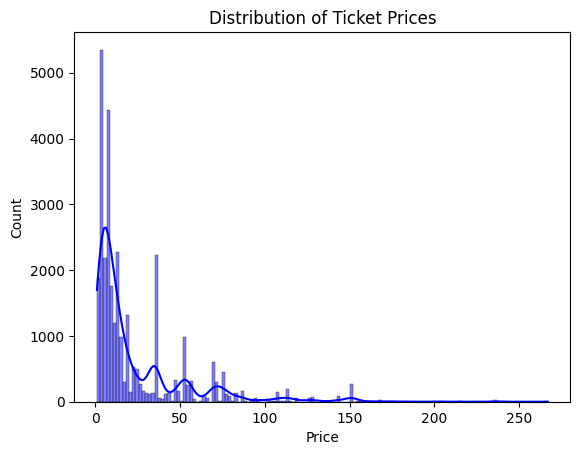

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Ticket Prices')

We notice that most tickets sold (High Demand) tickes are less than 50 $.

# 2. How many tickets bought in `Advance` compared to `Off-Peak` and `Anytime`? 🎫🎟️

/tmp/ipykernel_1466/15404195.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', palette='viridis')


Text(0.5, 1.0, 'Frequency of Ticket Types')

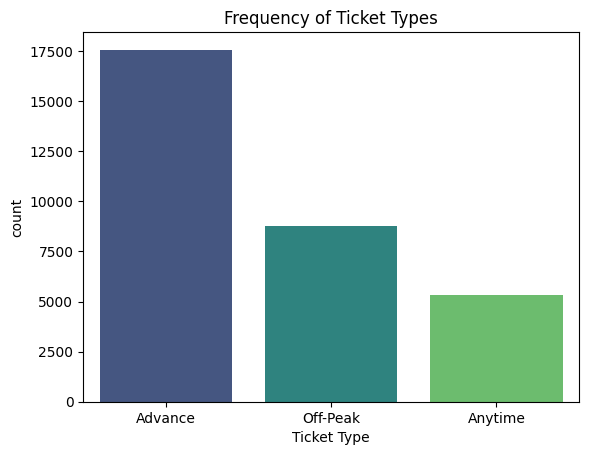

In [47]:
sns.countplot(data=df, x='Ticket Type', palette='viridis')
plt.title('Frequency of Ticket Types')

`Off-Peack` is nearly **50%** of the `Advance` demand while `Anytime` is nearly **30%**.

# 3. What is the trend of the `ticket prices`? and what is the AVG? 💵💸

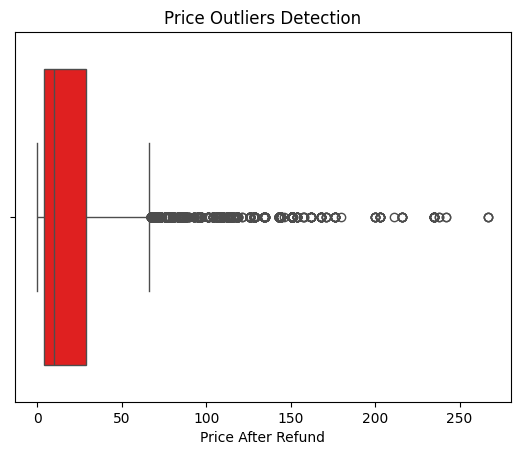

In [48]:
sns.boxplot(x=df['Price After Refund'], color='red')
plt.title('Price Outliers Detection')
plt.show()

In [49]:
avg_price = df['Price After Refund'].mean()

print(f"AVG. Ticket Price is: {avg_price.round(2)} £")

AVG. Ticket Price is: 22.22 £


# 4. What is top 10 train `routes` `high traffic`? 🚦🚸

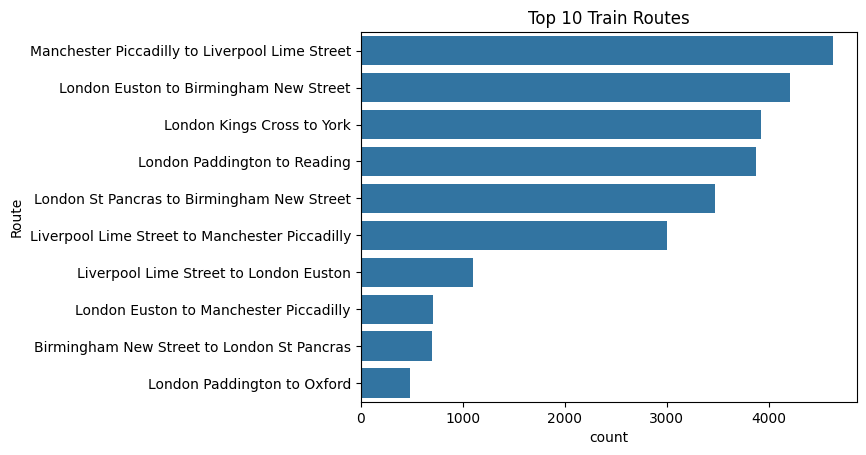

In [50]:
top_routes = df['Route'].value_counts().head(10).index

sns.countplot(data=df[df['Route'].isin(top_routes)], y='Route', order=top_routes)
plt.title('Top 10 Train Routes')
plt.show()

We notice that Manchester and Liverpool are the most stations in traffic, Manchester and Liverpool together are massivly traffic.

Let's see this in more depth

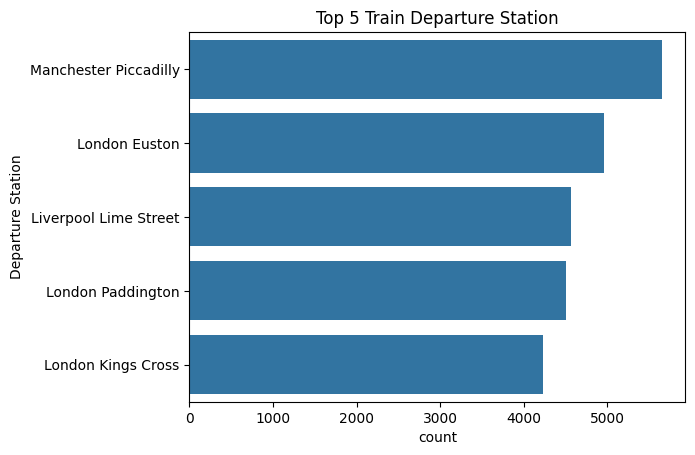

In [51]:
top_dep = df['Departure Station'].value_counts().head(5).index

sns.countplot(data=df[df['Departure Station'].isin(top_dep)], y='Departure Station', order=top_dep)
plt.title('Top 5 Train Departure Station')
plt.show()

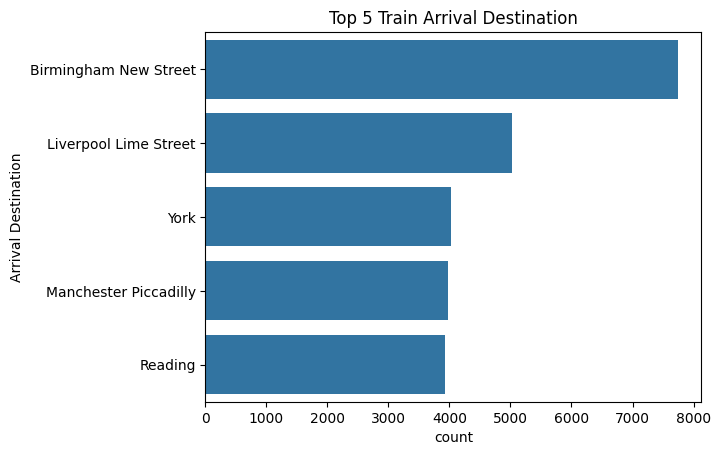

In [52]:
top_arr = df['Arrival Destination'].value_counts().head(5).index

sns.countplot(data=df[df['Arrival Destination'].isin(top_arr)], y='Arrival Destination', order=top_arr)
plt.title('Top 5 Train Arrival Destination')
plt.show()

# 6. Subscriptions

([<matplotlib.patches.Wedge at 0x7acd9fdc4500>,
 [Text(-0.532512279056471, 0.9625126870094146, 'No Railcard'),
  Text(-0.08697694263472013, -1.0965559773444842, 'Adult'),
  Text(0.7156849189531096, -0.8353413055650254, 'Disabled'),
  Text(1.0577961554913728, -0.301773579737643, 'Senior')],
 [Text(-0.2904612431217114, 0.5250069201869534, '66.1%'),
  Text(-0.04744196870984734, -0.5981214421879003, '15.3%'),
  Text(0.39037359215624157, -0.4556407121263774, '9.8%'),
  Text(0.5769797211771124, -0.16460377076598706, '8.8%')])

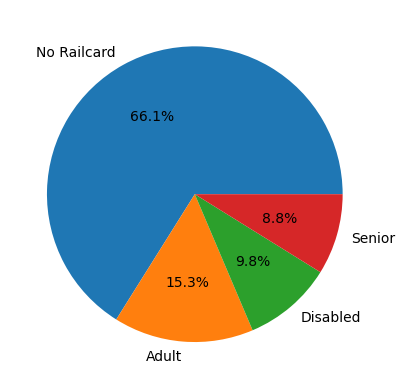

In [53]:
plt.pie(df['Railcard'].value_counts(), labels=df['Railcard'].value_counts().index, autopct='%1.1f%%')

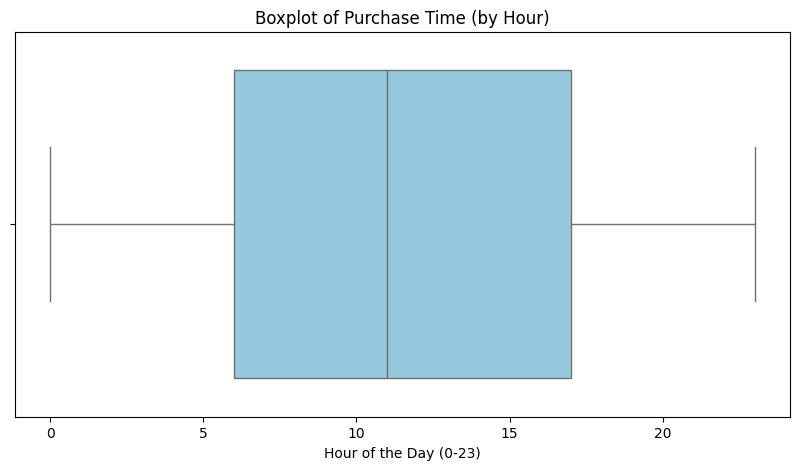

In [54]:
df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase'], format='%H:%M:%S')

df['Purchase Hour'] = df['Time of Purchase'].dt.hour

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Purchase Hour'], color='skyblue')

plt.title('Boxplot of Purchase Time (by Hour)')
plt.xlabel('Hour of the Day (0-23)')
plt.show()

# `** What is the overall distribution of operational performance (Journey Status) across the network?**`

/tmp/ipykernel_1466/1012441116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Journey Status', palette='Set2')


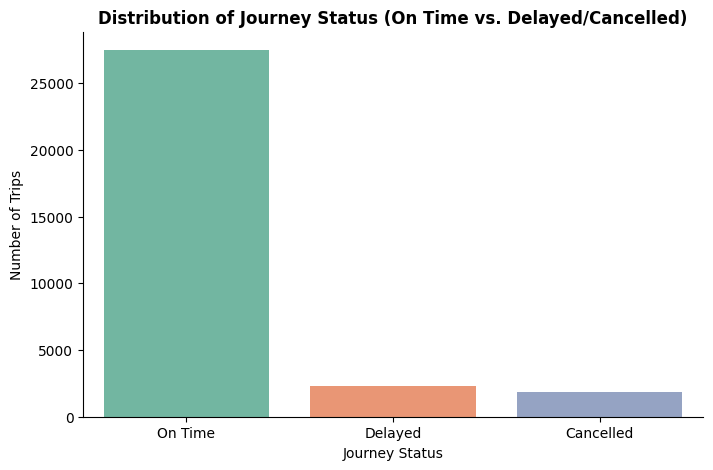

In [55]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Journey Status', palette='Set2')
plt.title('Distribution of Journey Status (On Time vs. Delayed/Cancelled)', fontsize=12, fontweight='bold')
plt.xlabel('Journey Status')
plt.ylabel('Number of Trips')
sns.despine()
plt.show()

`** What is the most popular Ticket Type purchased by our passengers?**`

/tmp/ipykernel_1466/1490336503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', palette='Blues_r')


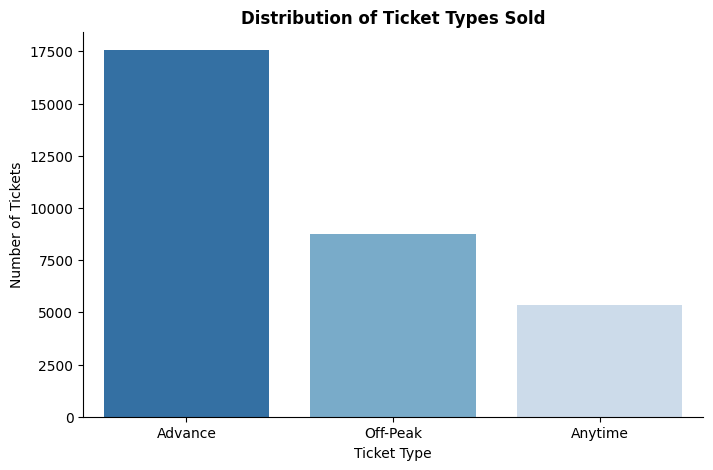

In [56]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Ticket Type', palette='Blues_r')
plt.title('Distribution of Ticket Types Sold', fontsize=12, fontweight='bold')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
sns.despine()
plt.show()

# ** How are ticket prices distributed, and what is the most common price range?**

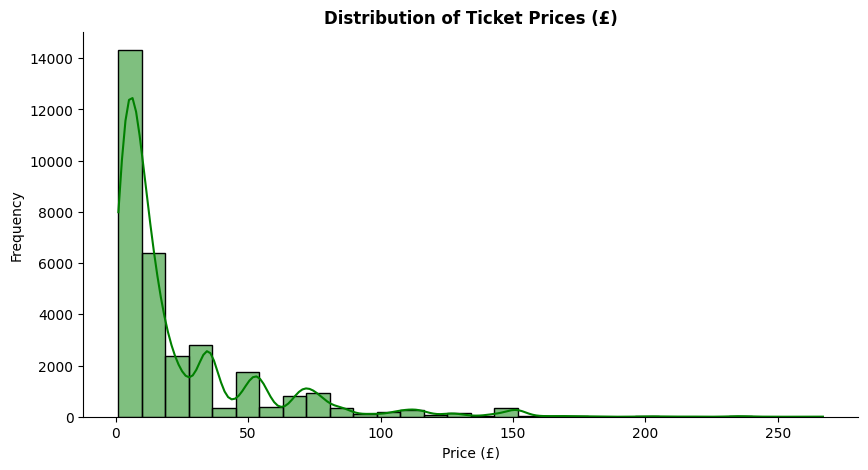

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='green')
plt.title('Distribution of Ticket Prices (£)', fontsize=12, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
sns.despine()
plt.show()

We conclude form this graph that:

- 50% of passengers boughts tickest from `6 AM` to `5 PM`
- Peak Time is in `11 AM`

# **`Bivariate Analysis`**


**In this section, we focus on Bivariate Analysis which primarily involves examining the relationship between two distinct variables simultaneously. The main objective is to uncover underlying patterns and identify cause-and-effect relationships within the data such as the impact of operational delay reasons on refund requests or how the ticket class influences total revenue. we have formulated 9 core Business Questions**



`1.   Which route generates the highest net revenue for the company?`

`2.   How does the Lead Time impact the ticket price?`

`3. What is the relative contribution of each ticket class to the overall revenue?`

`4. Which operational delay reason triggers the most refund requests and subsequent financial losses?`

`5. Which routes experience the highest frequency of delays and cancellations?`

`6. What is the average delay duration (in minutes) associated with each delay reason?`

`7. How does the day of the week (weekdays vs. weekends) impact the overall journey status?`

`8. Do Railcard holders show a distinct preference for specific ticket classes compared to passengers without Railcards?`

`9. Is there a noticeable relationship between the purchase type (Online vs. Station) and the chosen payment method?`

`10. How does the average total discount percentage vary across different ticket types?`

`11. Which train routes generate the highest average ticket prices?`

`12. How does the time of day (departure hour) impact the average delay duration?`

`13. How does the time of purchase influence the passenger's choice between Online and Station ticketing?`

`14. Is there a correlation between the length of a delay and the likelihood of a passenger requesting a refund?`

`15. Does holding a specific type of Railcard affect the likelihood of requesting a refund during disruptions?`

`16. Which 'Reason for Delay' results in the highest percentage of refund requests ?`









# 1. ` Which route generates the highest net revenue for the company?`






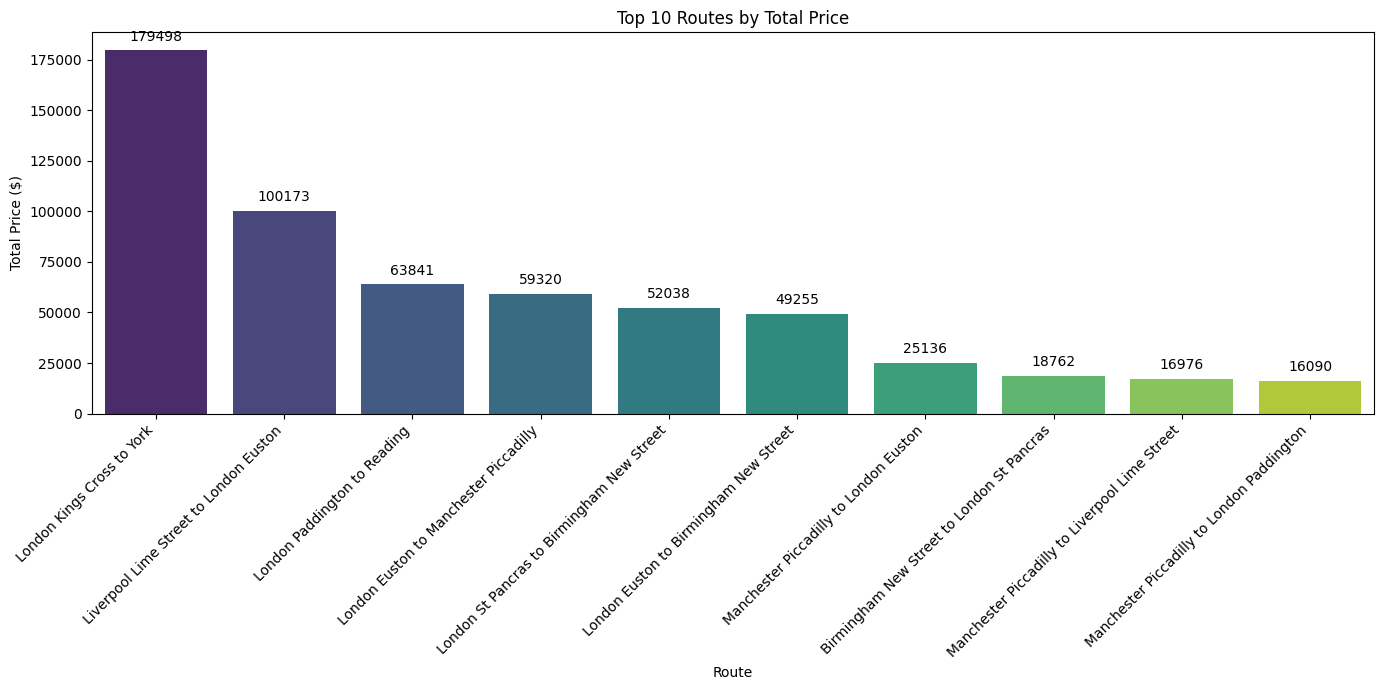

In [58]:
top_10_routes = df.groupby('Route')['Price After Refund'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=top_10_routes, x='Route', y='Price After Refund', hue='Route', palette='viridis', legend=False)
plt.title('Top 10 Routes by Total Price')
plt.xlabel('Route')
plt.ylabel('Total Price ($)')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

 `insight`

These top 10 routes represent the primary revenue-generating channels for the company. They are the most critical assets for maintaining consistent cash flow and overall profitability
these routes must be prioritized for proactive maintenance and resource allocation. Minimizing disruptions on these lines is essential to prevent significant financial leakage through refunds and lost sales

# 2. **`How does the Lead Time impact the ticket price?`**

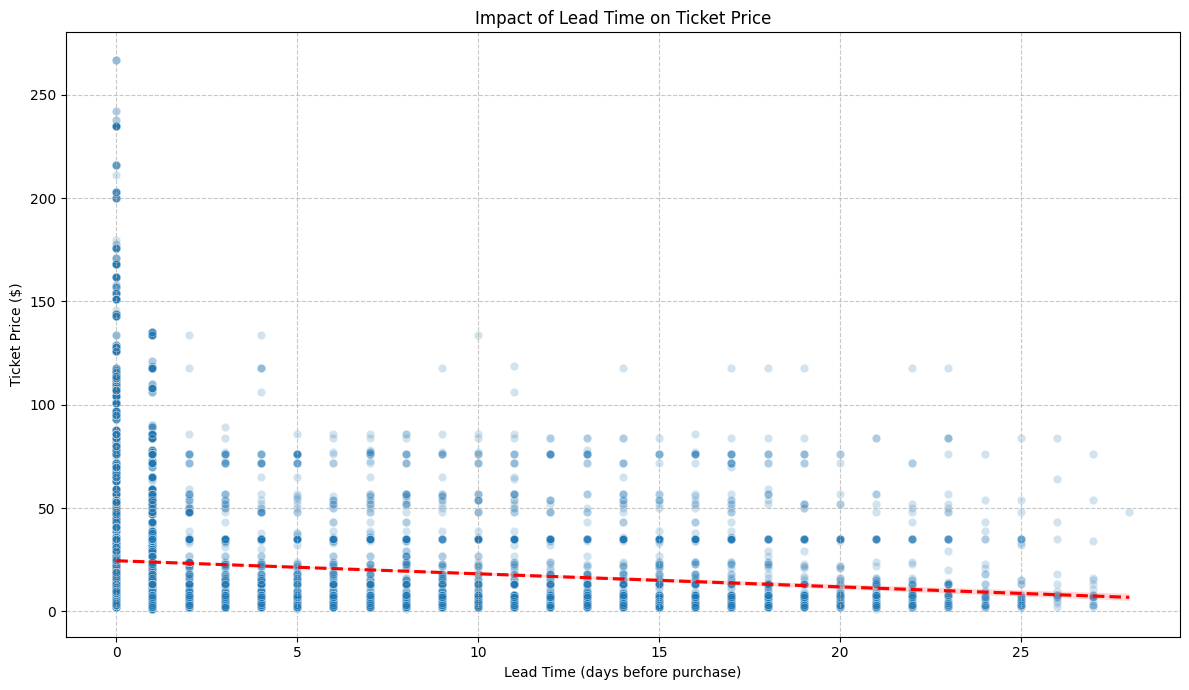

In [59]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Lead Time', y='Price', alpha=0.2)
sns.regplot(data=df, x='Lead Time', y='Price', scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Impact of Lead Time on Ticket Price')
plt.xlabel('Lead Time (days before purchase)')
plt.ylabel('Ticket Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **`Insight`**
ticket prices peak as the lead time approaches zero. This trend targets last-minute travelers who have low price sensitivity and urgent travel needs.

There is a clear correlation between early bookings and lower price points. To optimize cash flow, the company can introduce "Early Bird" incentives to secure advance revenue, while maintaining high margins on last-minute sales to maximize total yield.

# 3. **`What is the relative contribution of each ticket class to the overall revenue?`**

Revenue Breakdown by Ticket Class:
  Ticket Class   Price  Contribution (%)
0  First Class  149399          20.13678
1     Standard  592522          79.86322
------------------------------


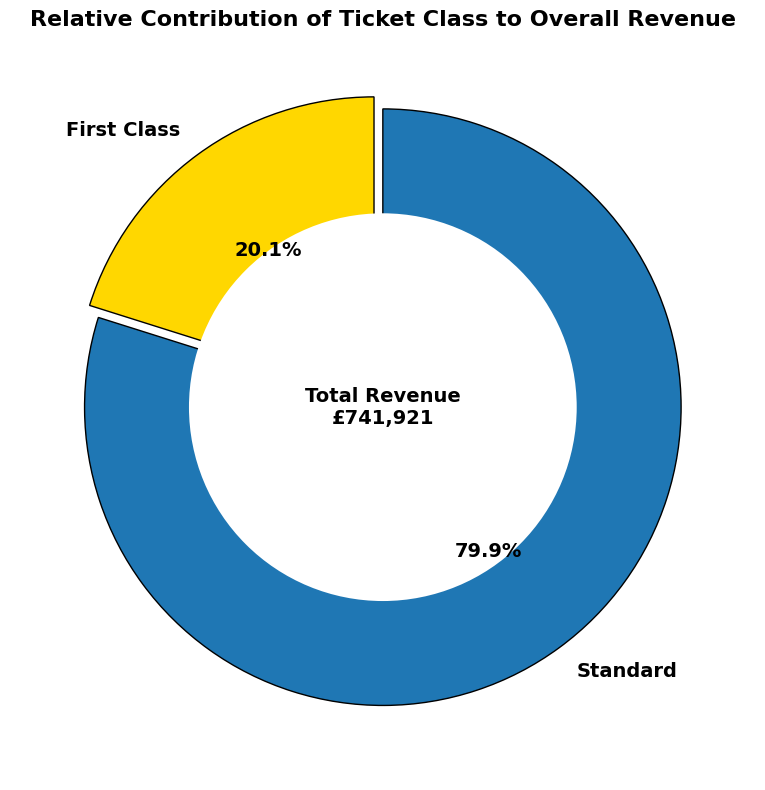

In [60]:
revenue_by_class = df.groupby('Ticket Class')['Price'].sum().reset_index()

total_revenue = revenue_by_class['Price'].sum()
revenue_by_class['Contribution (%)'] = (revenue_by_class['Price'] / total_revenue) * 100

print("Revenue Breakdown by Ticket Class:")
print(revenue_by_class)
print("-" * 30)

plt.figure(figsize=(8, 8))

colors = ['#FFD700', '#1f77b4']
explode = (0.05, 0)

plt.pie(revenue_by_class['Price'], labels=revenue_by_class['Ticket Class'],
        autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
        textprops={'fontsize': 14, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})


centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(0, 0, f'Total Revenue\n£{total_revenue:,.0f}', ha='center', va='center', fontsize=14, fontweight='bold', color='black')

plt.title('Relative Contribution of Ticket Class to Overall Revenue', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Which operational delay reason triggers the most refund requests and subsequent financial losses?

In [61]:
refund_requests_df = df[df['Refund Request'] == 'Yes']

refund_analysis = refund_requests_df.groupby('Reason for Delay').agg(
    Refund_Count=('Refund Request', 'size'),
    Financial_Loss=('Price', 'sum')
).reset_index()
refund_analysis_sorted = refund_analysis.sort_values(by='Financial_Loss', ascending=False)

display(refund_analysis_sorted)

,Reason for Delay,Refund_Count,Financial_Loss
2,Technical Issue,388,15046
1,Staff Shortage,261,11667
3,Traffic,121,4816
0,Signal Failure,215,4398
4,Weather Conditions,133,2775


/tmp/ipykernel_1466/2235627515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=refund_analysis_sorted_count, x='Refund_Count', y='Reason for Delay', palette='coolwarm')
/tmp/ipykernel_1466/2235627515.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=refund_analysis_sorted_loss, x='Financial_Loss', y='Reason for Delay', palette='viridis')


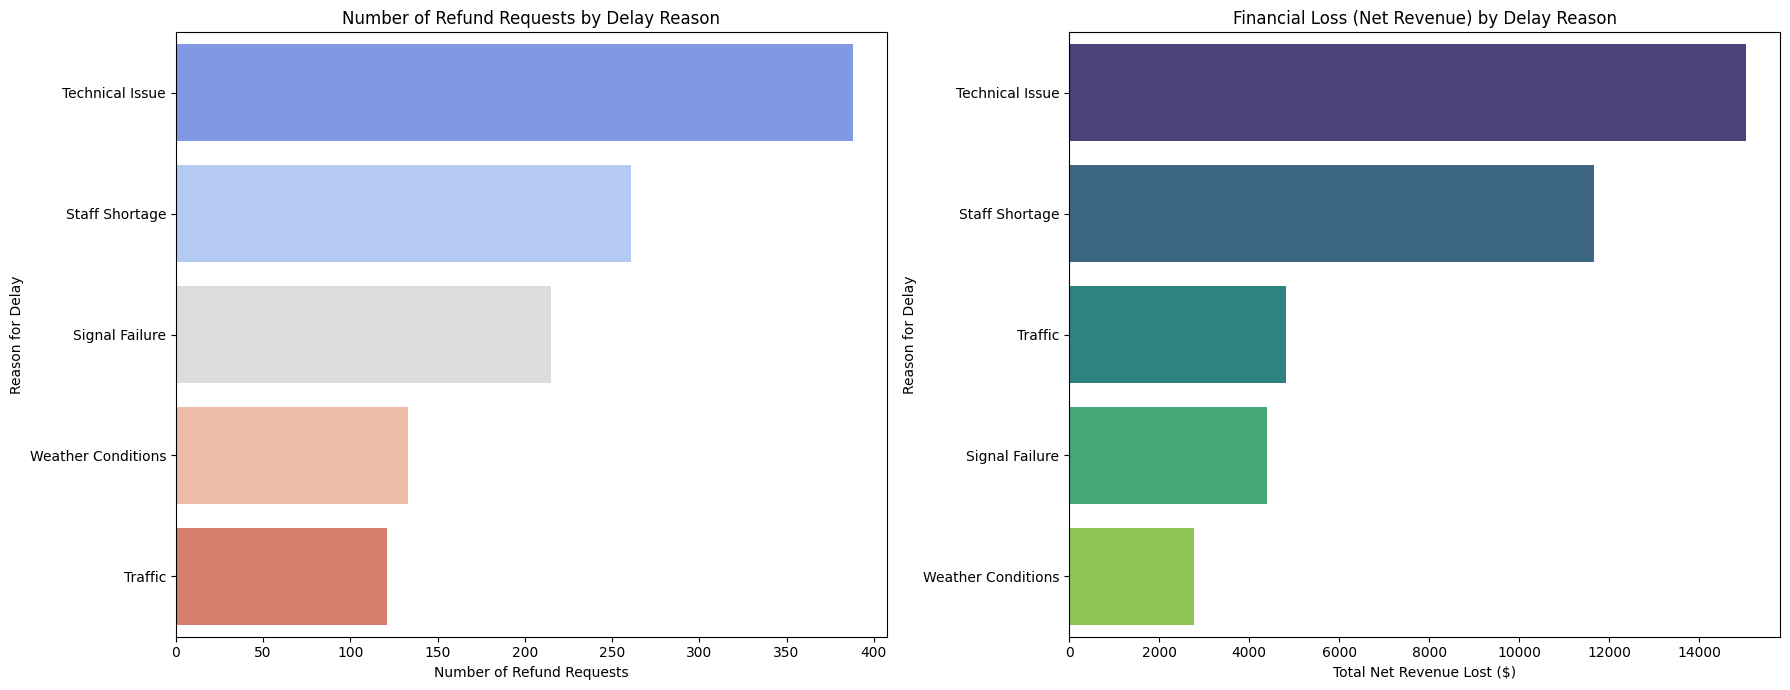

In [62]:
refund_analysis_sorted_count = refund_analysis.sort_values(by='Refund_Count', ascending=False)
refund_analysis_sorted_loss = refund_analysis.sort_values(by='Financial_Loss', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], data=refund_analysis_sorted_count, x='Refund_Count', y='Reason for Delay', palette='coolwarm')
axes[0].set_title('Number of Refund Requests by Delay Reason')
axes[0].set_xlabel('Number of Refund Requests')
axes[0].set_ylabel('Reason for Delay')


sns.barplot(ax=axes[1], data=refund_analysis_sorted_loss, x='Financial_Loss', y='Reason for Delay', palette='viridis')
axes[1].set_title('Financial Loss (Net Revenue) by Delay Reason')
axes[1].set_xlabel('Total Net Revenue Lost ($)')
axes[1].set_ylabel('Reason for Delay')

plt.tight_layout()
plt.show()

Let's check also the Avg. Delay Mins for each Reason for delay.

/tmp/ipykernel_1466/513445858.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg_delay_reason, x='Delay in Minutes', y='Reason for Delay', palette='magma', edgecolor='black')


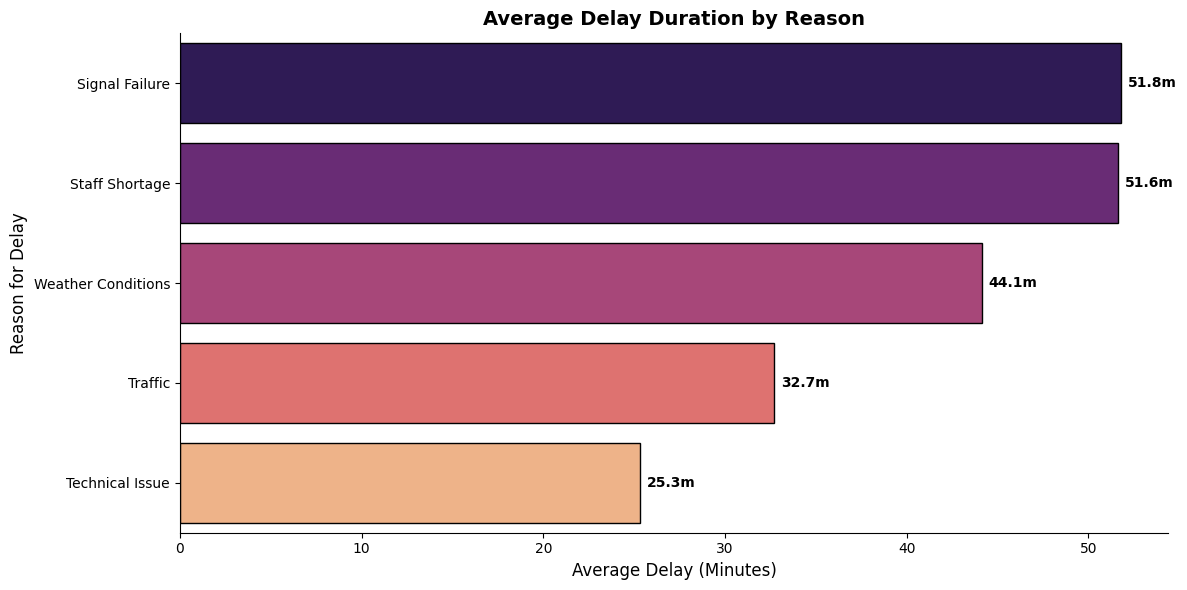

In [63]:
plt.figure(figsize=(12, 6))

# Filter for records where there was actually a delay and a reason provided
delay_reason_df = df[df['Delay in Minutes'] > 0].copy()

# Calculate average delay per reason
avg_delay_reason = delay_reason_df.groupby('Reason for Delay')['Delay in Minutes'].mean().sort_values(ascending=False).reset_index()

# Create the bar plot
ax = sns.barplot(data=avg_delay_reason, x='Delay in Minutes', y='Reason for Delay', palette='magma', edgecolor='black')

# Add data labels
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}m",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0),
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('Average Delay Duration by Reason', fontsize=14, fontweight='bold')
plt.xlabel('Average Delay (Minutes)', fontsize=12)
plt.ylabel('Reason for Delay', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

### 5. Which routes experience the highest frequency of delays and cancellations?

In [64]:

delays_cancellations_df = df[df['Journey Status'].isin(['Delayed', 'Cancelled'])]

route_impact = delays_cancellations_df.groupby('Route').size().reset_index(name='Frequency')

route_impact_sorted = route_impact.sort_values(by='Frequency', ascending=False)

display(route_impact_sorted.head(10))

,Route,Frequency
14,Liverpool Lime Street to London Euston,879
33,Manchester Piccadilly to Liverpool Lime Street,644
19,London Euston to Birmingham New Street,453
28,London Paddington to Reading,352
24,London Kings Cross to York,329
29,London St Pancras to Birmingham New Street,273
34,Manchester Piccadilly to London Euston,243
17,Liverpool Lime Street to Manchester Piccadilly,231
5,Birmingham New Street to Manchester Piccadilly,114
32,Manchester Piccadilly to Leeds,65


/tmp/ipykernel_1466/429191385.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_disrupted, y='Route', x='Disruption_Rate_%', palette='Reds_r')


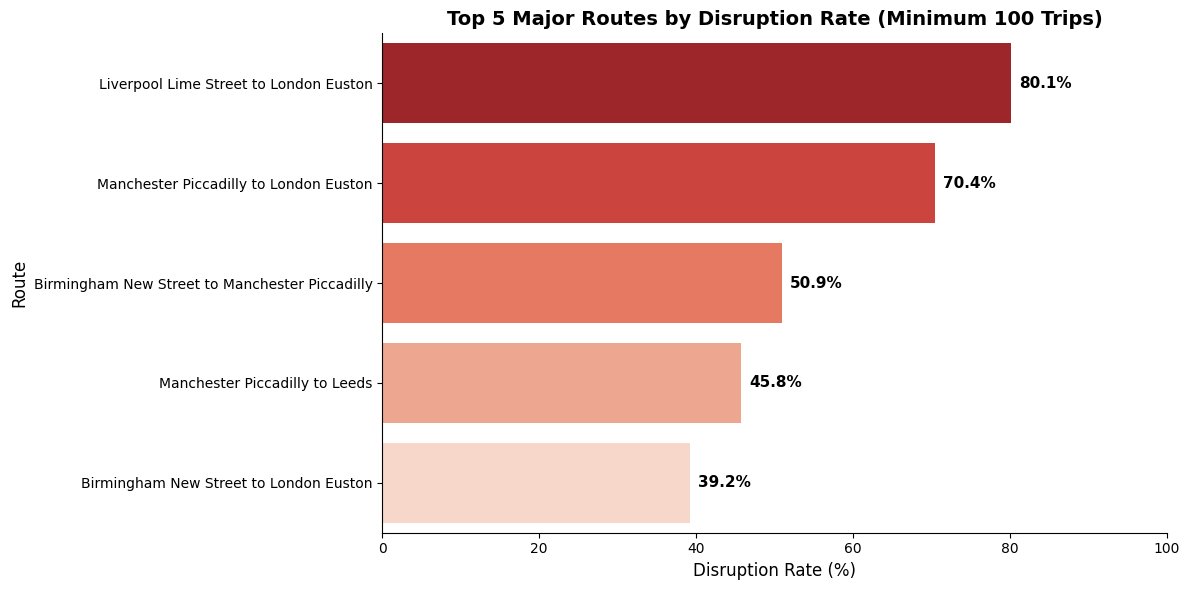

In [65]:

df['Is_Disrupted'] = df['Journey Status'].isin(['Delayed', 'Cancelled'])

route_stats = df.groupby('Route').agg(
    Total_Trips=('Transaction ID', 'count'),
    Disrupted_Trips=('Is_Disrupted', 'sum')
).reset_index()

route_stats['Disruption_Rate_%'] = (route_stats['Disrupted_Trips'] / route_stats['Total_Trips']) * 100

valid_routes = route_stats[route_stats['Total_Trips'] >= 100]

top_disrupted = valid_routes.sort_values(by='Disruption_Rate_%', ascending=False).head(5)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_disrupted, y='Route', x='Disruption_Rate_%', palette='Reds_r')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Top 5 Major Routes by Disruption Rate (Minimum 100 Trips)', fontsize=14, fontweight='bold')
plt.xlabel('Disruption Rate (%)', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.xlim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1466/2596813052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_impact_sorted.head(10), x='Frequency', y='Route', palette='coolwarm')


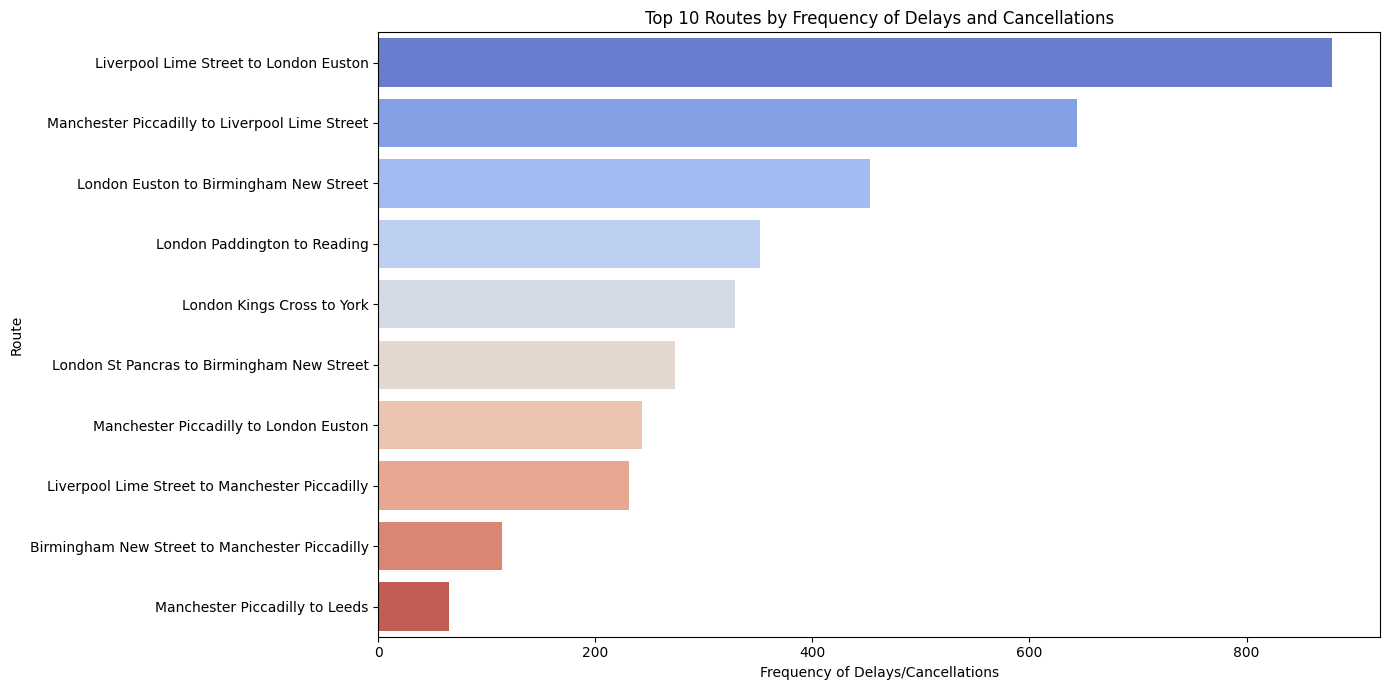

In [66]:
delays_cancellations_df = df[df['Journey Status'].isin(['Delayed', 'Cancelled'])]
route_impact = delays_cancellations_df.groupby('Route').size().reset_index(name='Frequency')
route_impact_sorted = route_impact.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=route_impact_sorted.head(10), x='Frequency', y='Route', palette='coolwarm')
plt.title('Top 10 Routes by Frequency of Delays and Cancellations')
plt.xlabel('Frequency of Delays/Cancellations')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

### 6. What is the average delay duration (in minutes) associated with each delay reason?

In [67]:
delayed_df = df[df['Reason for Delay'] != 'No Delay']

avg_delay_per_reason = delayed_df.groupby('Reason for Delay').agg(
    Average_Delay_Minutes=('Delay in Minutes', 'mean')
).reset_index()

avg_delay_sorted = avg_delay_per_reason.sort_values(by='Average_Delay_Minutes', ascending=False)

display(avg_delay_sorted)

,Reason for Delay,Average_Delay_Minutes
0,Signal Failure,51.811530
1,Staff Shortage,51.180282
4,Weather Conditions,43.842503
3,Traffic,32.344828
2,Technical Issue,24.917373


7. How does the day of the week (weekdays vs. weekends) impact the overall journey status?

In [68]:
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])

df['Day Name'] = df['Date of Journey'].dt.day_name()
df['Day Type'] = df['Day Name'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

day_impact = df.groupby(['Day Type', 'Journey Status']).size().reset_index(name='Count')

total_per_day_type = day_impact.groupby('Day Type')['Count'].transform('sum')
day_impact['Percentage (%)'] = ((day_impact['Count'] / total_per_day_type) * 100).round(2)

pivot_impact = day_impact.pivot(index='Journey Status', columns='Day Type', values='Percentage (%)')

display(pivot_impact)

Day Type,Weekday,Weekend
Journey Status,,
Cancelled,5.70,6.53
Delayed,7.49,6.61
On Time,86.80,86.86


8.  Do Railcard holders show a distinct preference for specific ticket classes compared to passengers without Railcards?

In [69]:
df['Has_Railcard'] = df['Railcard'].apply(lambda x: 'No' if x == 'No Railcard' else 'Yes')

preference_df = df.groupby(['Has_Railcard', 'Ticket Class']).size().reset_index(name='Count')

total_per_group = preference_df.groupby('Has_Railcard')['Count'].transform('sum')
preference_df['Preference (%)'] = ((preference_df['Count'] / total_per_group) * 100).round(2)

pivot_preference = preference_df.pivot(index='Has_Railcard', columns='Ticket Class', values='Preference (%)')

display(pivot_preference)

Ticket Class,First Class,Standard
Has_Railcard,,
No,9.49,90.51
Yes,10.00,90.00


9. Is there a noticeable relationship between the purchase type (Online vs. Station) and the chosen payment method?

In [70]:
purchase_payment_crosstab = pd.crosstab(
    df['Purchase Type'],
    df['Payment Method'],
    normalize='index'
) * 100

purchase_payment_crosstab = purchase_payment_crosstab.round(2)

display(purchase_payment_crosstab)

Payment Method,Contactless,Credit Card,Debit Card
Purchase Type,,,
Online,34.50,62.02,3.48
Station,33.84,58.25,7.91


`10. How does the average total discount percentage vary across different ticket types?`

/tmp/ipykernel_1466/1000870121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q1_data, x='Ticket Type', y='Total Discount %', palette='Blues_r', edgecolor='black')


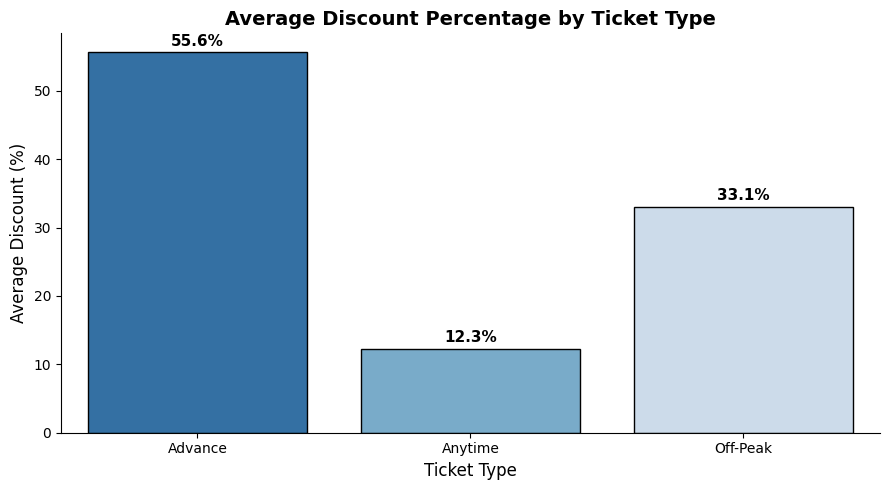

In [71]:
plt.figure(figsize=(9, 5))
q1_data = df.groupby('Ticket Type')['Total Discount %'].mean().reset_index()
q1_data['Total Discount %'] *= 100

ax = sns.barplot(data=q1_data, x='Ticket Type', y='Total Discount %', palette='Blues_r', edgecolor='black')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Average Discount Percentage by Ticket Type', fontsize=14, fontweight='bold')
plt.ylabel('Average Discount (%)', fontsize=12)
plt.xlabel('Ticket Type', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

`11. Which train routes generate the highest average ticket prices?`

/tmp/ipykernel_1466/3264543225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q2_data, y='Route', x='Price After Refund', palette='viridis', edgecolor='black')


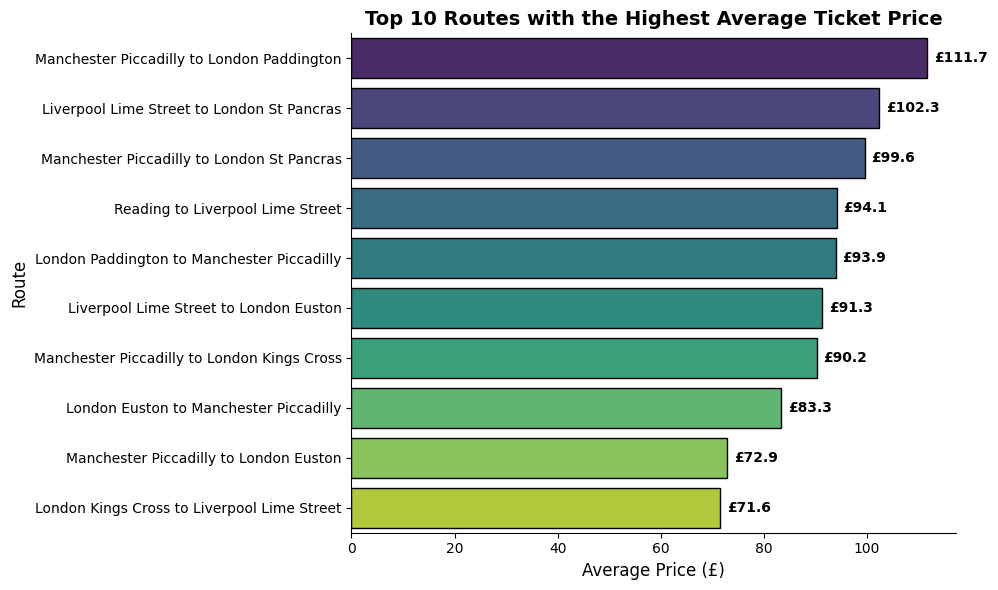

In [72]:
plt.figure(figsize=(10, 6))
q2_data = df.groupby('Route')['Price After Refund'].mean().sort_values(ascending=False).head(10).reset_index()

ax = sns.barplot(data=q2_data, y='Route', x='Price After Refund', palette='viridis', edgecolor='black')

for p in ax.patches:
    ax.annotate(f"£{p.get_width():.1f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0),
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('Top 10 Routes with the Highest Average Ticket Price', fontsize=14, fontweight='bold')
plt.xlabel('Average Price (£)', fontsize=12)
plt.ylabel('Route', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

`12. How does the time of day (departure hour) impact the average delay duration?`

/tmp/ipykernel_1466/4123603591.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure Time'] = pd.to_datetime(df['Departure Time'])


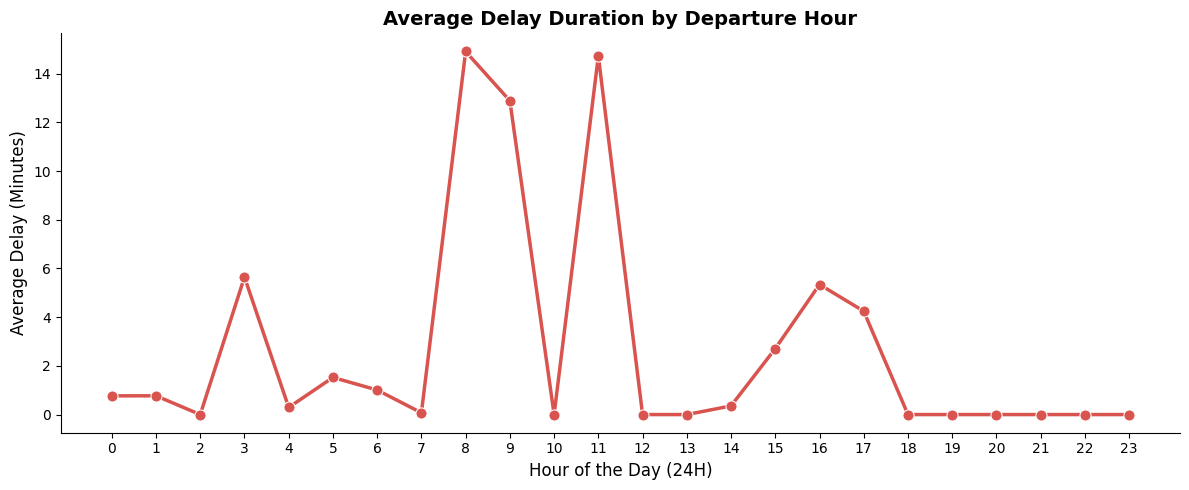

In [73]:
plt.figure(figsize=(12, 5))
# Convert 'Departure Time' to datetime if it's not already
df['Departure Time'] = pd.to_datetime(df['Departure Time'])
df['Departure Hour'] = df['Departure Time'].dt.hour
q3_data = df.groupby('Departure Hour')['Delay in Minutes'].mean().reset_index()

ax = sns.lineplot(data=q3_data, x='Departure Hour', y='Delay in Minutes',
                  marker='o', color='#d9534f', linewidth=2.5, markersize=8)

plt.title('Average Delay Duration by Departure Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24H)', fontsize=12)
plt.ylabel('Average Delay (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
sns.despine()
plt.tight_layout()
plt.show()

`13. How does the time of purchase influence the passenger's choice between Online and Station ticketing?`

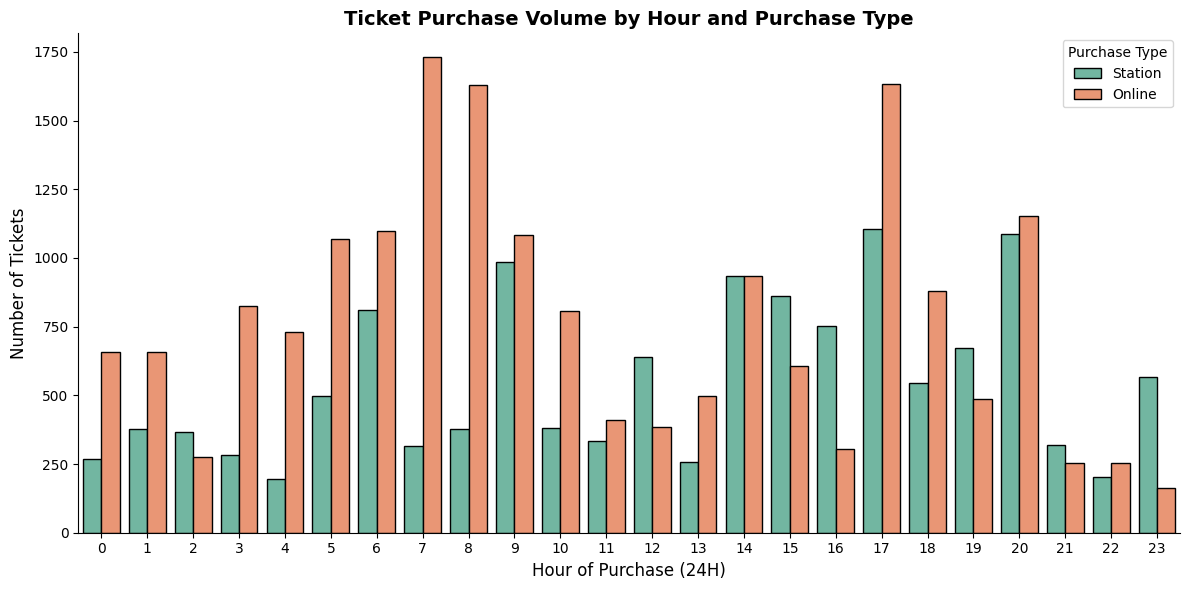

In [74]:
plt.figure(figsize=(12, 6))
df['Purchase Hour'] = df['Time of Purchase'].dt.hour
sns.countplot(data=df, x='Purchase Hour', hue='Purchase Type', palette='Set2', edgecolor='black')
plt.title('Ticket Purchase Volume by Hour and Purchase Type', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Purchase (24H)', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.legend(title='Purchase Type')
sns.despine()
plt.tight_layout()
plt.show()

`14. Is there a correlation between the length of a delay and the likelihood of a passenger requesting a refund?`

/tmp/ipykernel_1466/2478683810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delayed_df, x='Refund Request', y='Delay in Minutes',


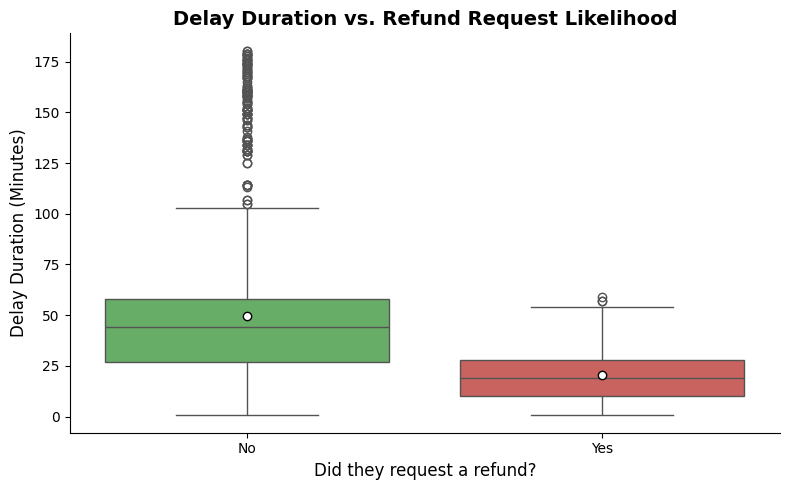

In [75]:
plt.figure(figsize=(8, 5))
delayed_df = df[df['Delay in Minutes'] > 0].copy()
sns.boxplot(data=delayed_df, x='Refund Request', y='Delay in Minutes',
            palette=['#5cb85c', '#d9534f'], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Delay Duration vs. Refund Request Likelihood', fontsize=14, fontweight='bold')
plt.xlabel('Did they request a refund?', fontsize=12)
plt.ylabel('Delay Duration (Minutes)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

`15. Does holding a specific type of Railcard affect the likelihood of requesting a refund during disruptions?`

/tmp/ipykernel_1466/3244308014.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q6_data, x='Refund_Numeric', y='Railcard', palette='magma', edgecolor='black')


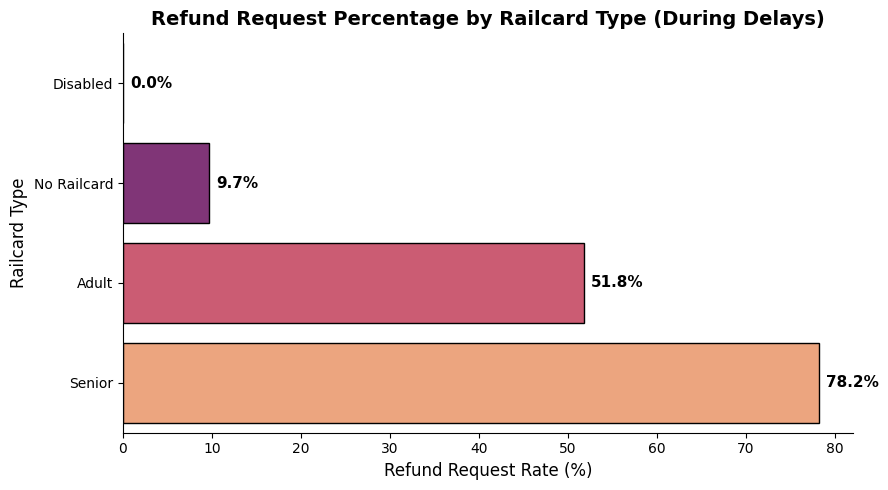

In [76]:
plt.figure(figsize=(9, 5))

delayed_df['Refund_Numeric'] = np.where(delayed_df['Refund Request'] == 'Yes', 1, 0)
q6_data = (delayed_df.groupby('Railcard')['Refund_Numeric'].mean() * 100).sort_values().reset_index()

ax = sns.barplot(data=q6_data, x='Refund_Numeric', y='Railcard', palette='magma', edgecolor='black')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Refund Request Percentage by Railcard Type (During Delays)', fontsize=14, fontweight='bold')
plt.xlabel('Refund Request Rate (%)', fontsize=12)
plt.ylabel('Railcard Type', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

`16. Which 'Reason for Delay' results in the highest percentage of refund requests ?`

/tmp/ipykernel_1466/103378321.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=alt2_data, y='Reason for Delay', x='Refund_Num', palette='Reds_r', edgecolor='black')


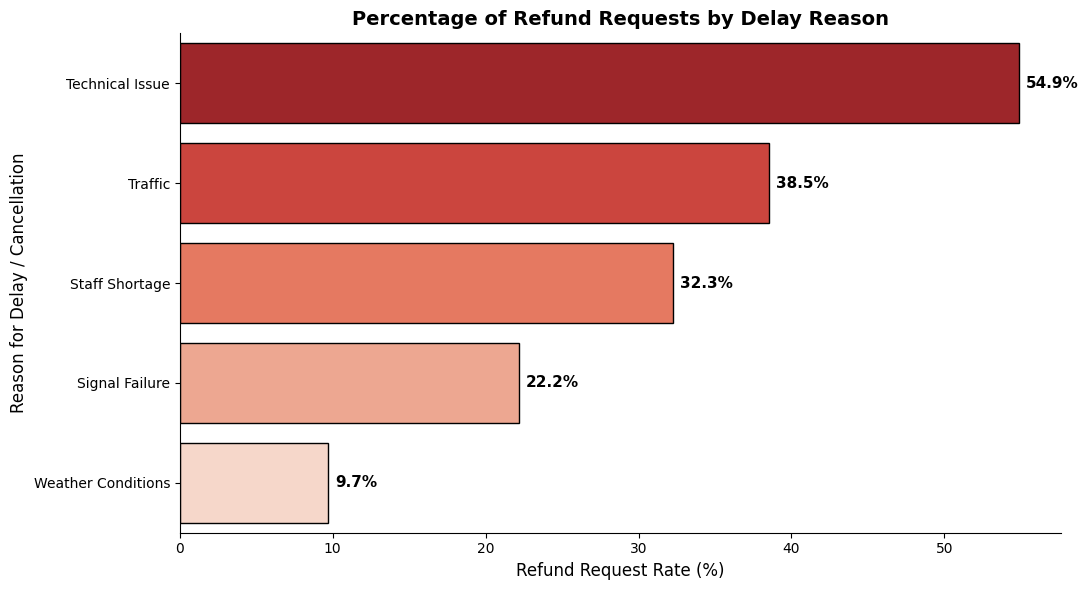

In [77]:
plt.figure(figsize=(11, 6))
delayed_df = df[df['Journey Status'].isin(['Delayed', 'Cancelled'])].copy()
delayed_df['Refund_Num'] = np.where(delayed_df['Refund Request'] == 'Yes', 1, 0)

alt2_data = (delayed_df.groupby('Reason for Delay')['Refund_Num'].mean() * 100).sort_values(ascending=False).reset_index()

ax = sns.barplot(data=alt2_data, y='Reason for Delay', x='Refund_Num', palette='Reds_r', edgecolor='black')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Percentage of Refund Requests by Delay Reason', fontsize=14, fontweight='bold')
plt.xlabel('Refund Request Rate (%)', fontsize=12)
plt.ylabel('Reason for Delay / Cancellation', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

# **`Multivariate Analsis`**

this section, we transition to Multivariate Analysis, which involves examining
the complex interactions between three or more variables simultaneously. The main objective is to uncover deeper, multidimensional patterns and hidden operational bottlenecks within the data—such as how the combination of departure hours and ticket types exposes potential revenue leakage through discounts, or how specific delay reasons impact average delay durations across different routes. To address these complex dynamics, we have formulated 6 advanced Business Question

`1. How does the average ticket price vary across the top 5 busiest routes when comparing different Ticket Types (Advance, Off-Peak, Anytime ?`

`2. Which routes experience the highest average delay minutes during specific times of the day ?`

`3. Does the ticket class (First vs. Standard) influence the likelihood of a refund request across different delay durations ?`

`4. How does the average discount percentage vary across different departure hours when comparing Ticket Types ?`

`5. Which combination of Route and Reason for Delay results in the longest average delay duration?`




`1. How does the average ticket price vary across the top 5 busiest routes when comparing different Ticket Types (Advance, Off-Peak, Anytime ?`

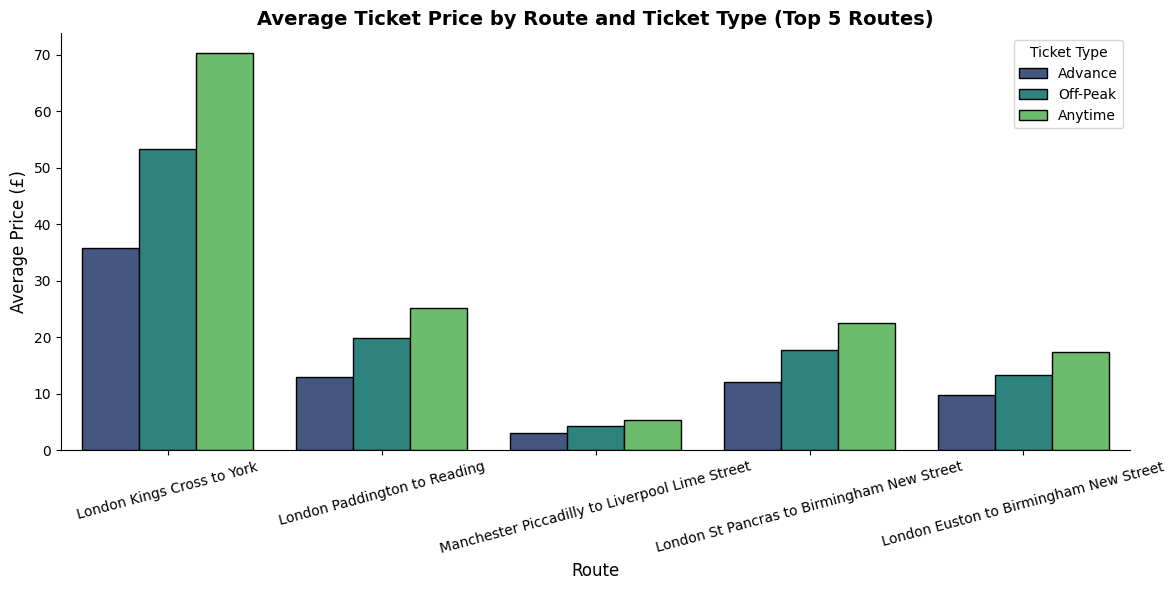

In [78]:
plt.figure(figsize=(12, 6))
top_5_routes = df['Route'].value_counts().head(5).index
filtered_df = df[df['Route'].isin(top_5_routes)]
ax = sns.barplot(data=filtered_df, x='Route', y='Price', hue='Ticket Type',
                 palette='viridis', edgecolor='black', errorbar=None)

plt.title('Average Ticket Price by Route and Ticket Type (Top 5 Routes)', fontsize=14, fontweight='bold')
plt.xlabel('Route', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Ticket Type')
sns.despine()
plt.tight_layout()
plt.show()

`Insight`

observation: > An analysis of the top 5 busiest routes reveals a massive price disparity between 'Anytime' and 'Advance' ticket categories. Despite being the highest-demand routes, a large volume of tickets is being sold at the heavily discounted 'Advance' rate.

Business Impact (The "So What?"): > Since these specific routes experience consistently high passenger volume (inelastic demand), offering steep discounts represents a significant case of Revenue Leakage. The company is essentially sacrificing profit margins on passengers who are highly likely to travel regardless of the discount.

Recommendation: > Optimize the current Yield Management strategy by either reducing the allocation limit or decreasing the discount percentage for 'Advance' tickets exclusively on these top 5 routes. This minor adjustment will naturally shift passenger purchases toward 'Off-Peak' and 'Anytime' tiers, directly maximizing overall revenue without incurring any additional operational cost

`2. Which routes experience the highest average delay minutes during specific times of the day ?`

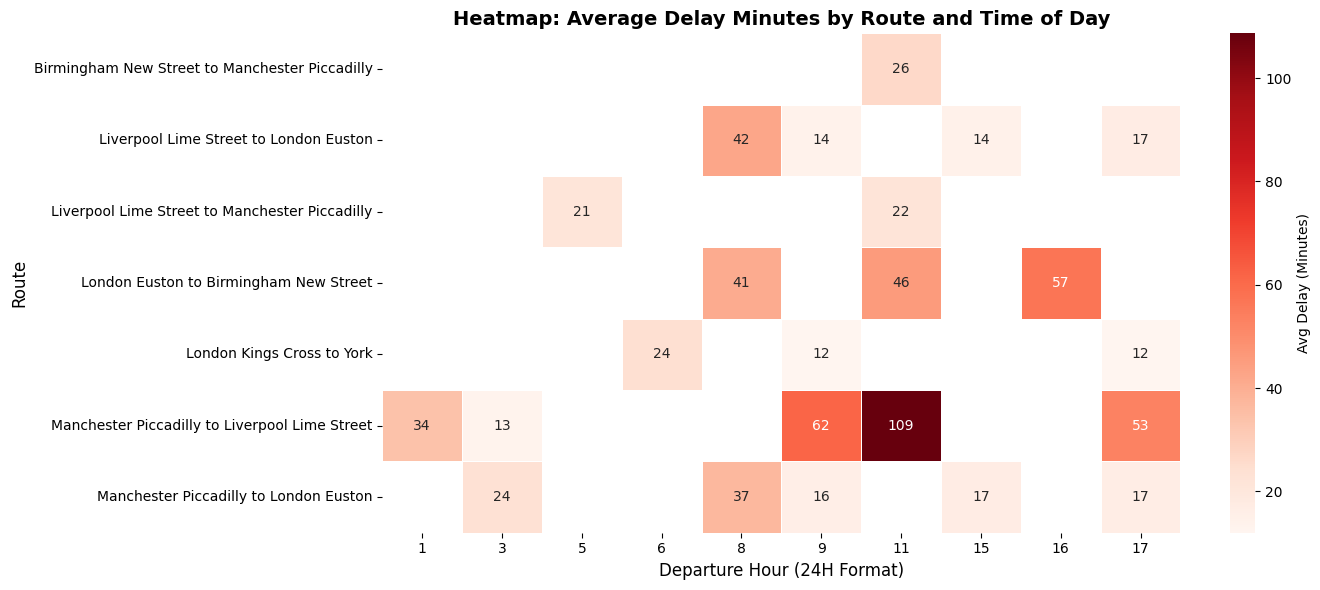

In [79]:
delayed_df = df[df['Delay in Minutes'] > 0].copy()

# استخراج ساعة المغادرة من وقت المغادرة
delayed_df['Departure Hour'] = pd.to_datetime(delayed_df['Departure Time']).dt.hour

# اختيار أكبر 7 مسارات عشان الرسمة تكون واضحة
top_routes = delayed_df['Route'].value_counts().head(7).index
heat_df = delayed_df[delayed_df['Route'].isin(top_routes)]

# تجهيز الداتا للـ Heatmap (متوسط التأخير لكل مسار في كل ساعة)
pivot_df = heat_df.pivot_table(index='Route', columns='Departure Hour', values='Delay in Minutes', aggfunc='mean')

plt.figure(figsize=(14, 6))
# رسم الخريطة الحرارية (اللون الأحمر الغامق يعني تأخير طويل جداً)
sns.heatmap(pivot_df, cmap='Reds', annot=True, fmt=".0f", linewidths=.5, cbar_kws={'label': 'Avg Delay (Minutes)'})

plt.title('Heatmap: Average Delay Minutes by Route and Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Departure Hour (24H Format)', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.tight_layout()
plt.show()

In [80]:
print(f"Missing cells in heatmap: {pivot_df.isna().sum().sum()}")
print(f"Heatmap shape: {pivot_df.shape}")

Missing cells in heatmap: 47
Heatmap shape: (7, 10)


`3. Does the ticket class (First vs. Standard) influence the likelihood of a refund request across different delay durations ?`

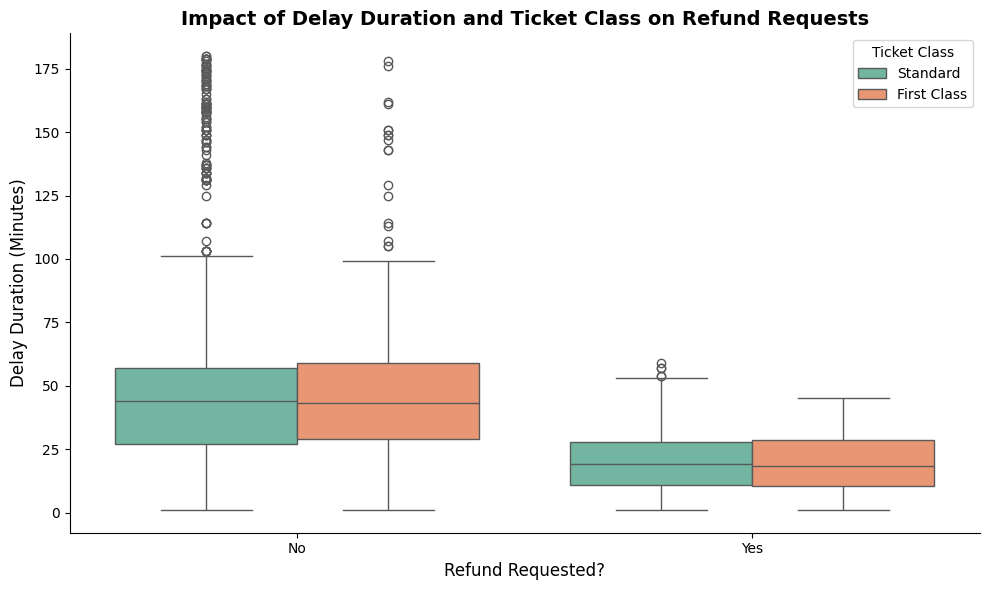

In [81]:
plt.figure(figsize=(10, 6))
delayed_only = df[df['Delay in Minutes'] > 0]

sns.boxplot(data=delayed_only, x='Refund Request', y='Delay in Minutes',
            hue='Ticket Class', palette='Set2')

plt.title('Impact of Delay Duration and Ticket Class on Refund Requests', fontsize=14, fontweight='bold')
plt.xlabel('Refund Requested?', fontsize=12)
plt.ylabel('Delay Duration (Minutes)', fontsize=12)
plt.legend(title='Ticket Class')
sns.despine()
plt.tight_layout()
plt.show()

We can deduce that the systems of UK Train automaticly refund after 60 min of delay. So passengers do not request refund.

`4. How does the average discount percentage vary across different departure hours when comparing Ticket Types ?`

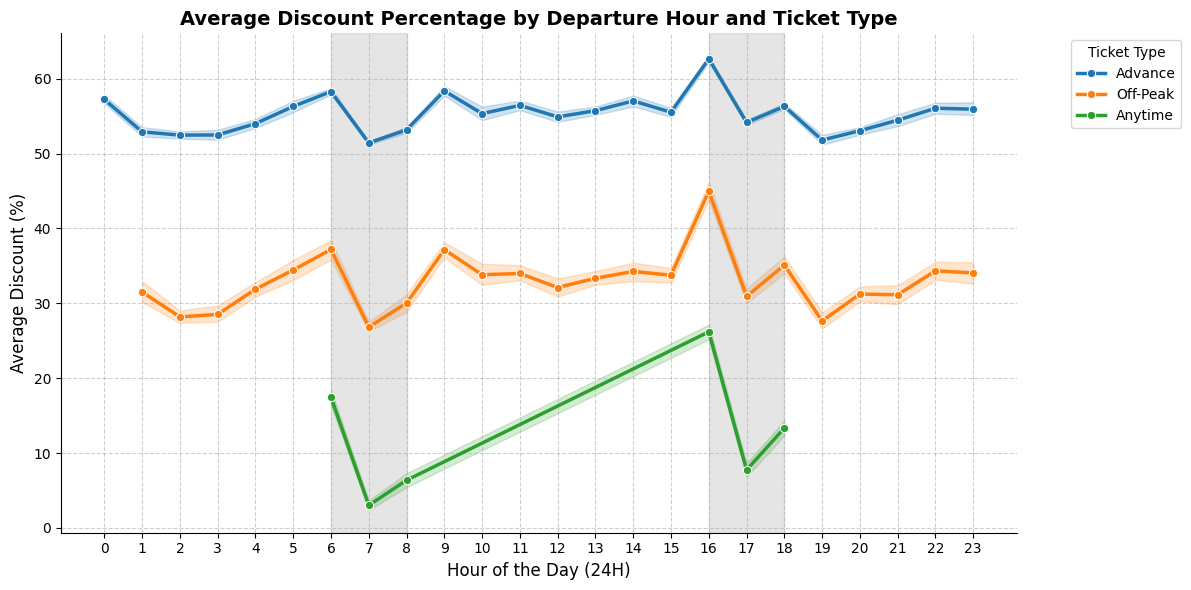

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

df['Departure Hour'] = df['Departure Time'].dt.hour

df['Discount_Percentage'] = df['Total Discount %'] * 100

sns.lineplot(data=df, x='Departure Hour', y='Discount_Percentage', hue='Ticket Type',
             marker='o', linewidth=2.5, palette='tab10')

plt.title('Average Discount Percentage by Departure Hour and Ticket Type', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24H)', fontsize=12)
plt.ylabel('Average Discount (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Highlight periods 6-8 and 16-18
plt.axvspan(6, 8, color='gray', alpha=0.2, label='Highlighted Periods')
plt.axvspan(16, 18, color='gray', alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

`5. Which combination of Route and Reason for Delay results in the longest average delay duration?`

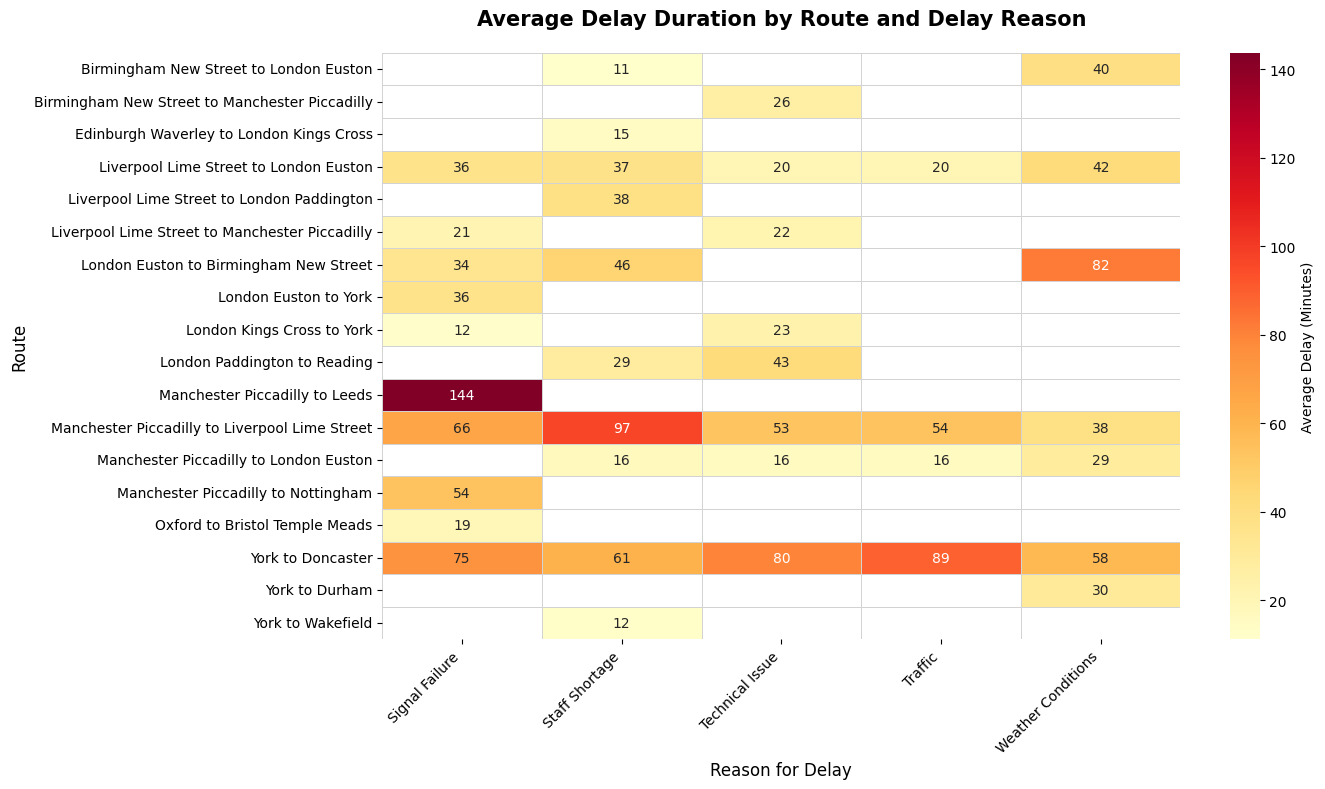

In [83]:
plt.figure(figsize=(14, 8))

delayed_df = df[df['Journey Status'].isin(['Delayed', 'Cancelled'])].copy()

maintenance_pivot = delayed_df.pivot_table(index='Route', columns='Reason for Delay',
                                           values='Delay in Minutes', aggfunc='mean')


sns.heatmap(maintenance_pivot, cmap='YlOrRd', linewidths=0.5, linecolor='lightgray',
            annot=True, fmt=".0f",
            cbar_kws={'label': 'Average Delay (Minutes)'})

plt.title('Average Delay Duration by Route and Delay Reason', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Reason for Delay', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Hypothesis

- **Hypothesis 1:** Does selling Advance (have a 50% discount) tikets during peak morning and evening hour significently increase total revenue compared to selling Anytime tikets (at full price)

- **Hypothesis 2:** Tickets purchased at the Station have a higher average price than those purchased Online.

- **Hypothesis 3:** First Class tickets are primarily purchased for long-distance routes.

- **Hypothesis 4:** Credit Card transactions have a higher average value compared to Debit Card transactions.

- **Hypothesis 5:** Journeys scheduled during Rush Hour (07:00–09:00) are more likely to be delayed than normal journeys.

- **Hypothesis 6:** Technical issues as a cause for delay are station-specific.

- **Hypothesis 7:** Online purchasers are more likely to request refunds through the system than Station purchasers.

- **Hypothesis 8:** First Class passengers are less likely to request a refund compared to other classes.

- **Hypothesis 9:** As the lead time between purchase and travel increases, the refund rate also increases.

### Hypothesis 1: Does selling Advance (with a 50% discount) tickets during peak morning and evening hours significantly increase total revenue compared to selling Anytime tickets (at full price)?

/tmp/ipykernel_1466/3267899945.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=peak_revenue, x='Ticket Type', y='Price After Refund', palette='Reds_r', edgecolor='black')


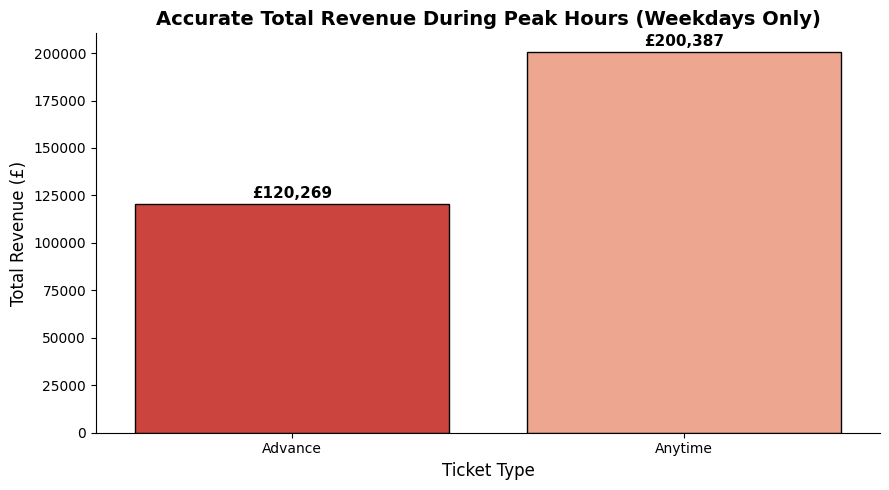

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])
df['Departure Hour'] = pd.to_datetime(df['Departure Time'], format='%H:%M:%S').dt.hour

df['Day of Week'] = df['Date of Journey'].dt.dayofweek

def classify_peak_accurate(row):
    hour = row['Departure Hour']
    day = row['Day of Week']

    if day < 5 and ((6 <= hour <= 8) or (16 <= hour <= 18)):
        return 'Peak Hours'
    return 'Off-Peak Hours'

# تطبيق الدالة على الداتا كلها (axis=1 عشان بنستخدم أكتر من عمود)
df['Time Category'] = df.apply(classify_peak_accurate, axis=1)

# حساب الإيرادات زي ما عملنا قبل كده
peak_revenue = df[df['Time Category'] == 'Peak Hours'].groupby('Ticket Type')['Price After Refund'].sum().reset_index()

# الرسم
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=peak_revenue, x='Ticket Type', y='Price After Refund', palette='Reds_r', edgecolor='black')

for p in ax.patches:
    ax.annotate(f"£{p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Accurate Total Revenue During Peak Hours (Weekdays Only)', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Type', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

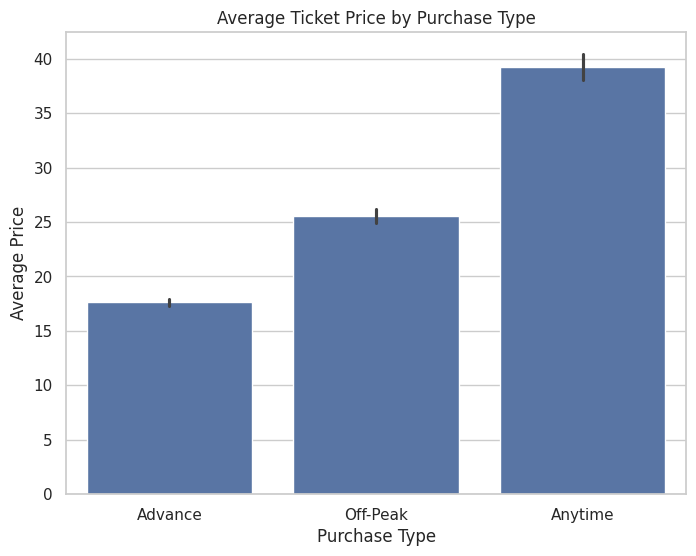

In [85]:
# Hypothesis 2: Tickets purchased at the Station have a higher average price than those purchased Online.
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
barplot = sns.barplot(data=df, x='Ticket Type', y='Price',)

plt.title('Average Ticket Price by Purchase Type')
plt.ylabel('Average Price')
plt.xlabel('Purchase Type')

plt.show()

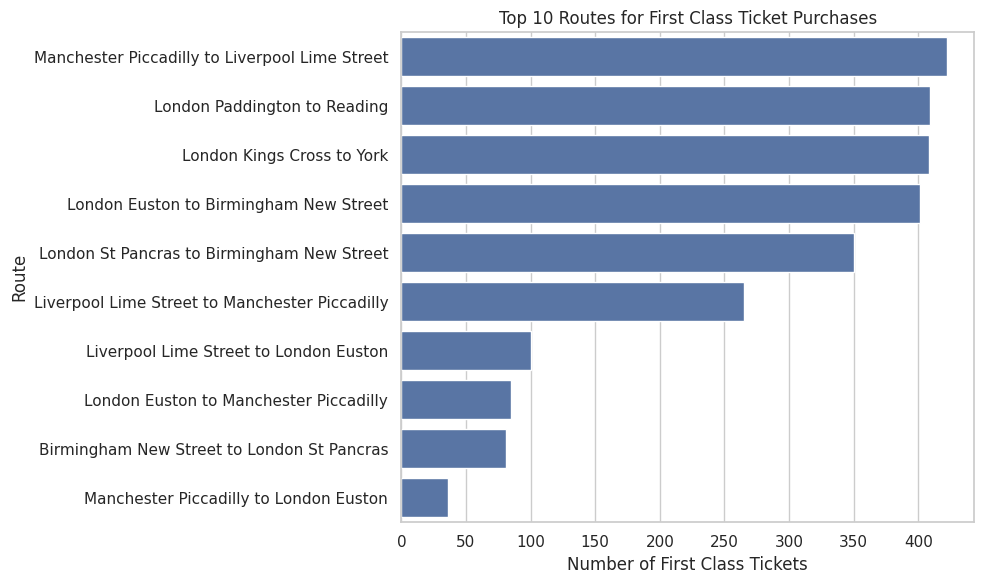

In [86]:
# Hypothesis 3: First Class tickets are primarily purchased for long-distance routes.
first_class_df = df[df['Ticket Class'] == 'First Class']
route_counts = first_class_df['Route'].value_counts().reset_index()
route_counts.columns = ['Route', 'Count']
top_routes = route_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_routes, x='Count', y='Route')
plt.title('Top 10 Routes for First Class Ticket Purchases')
plt.xlabel('Number of First Class Tickets')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

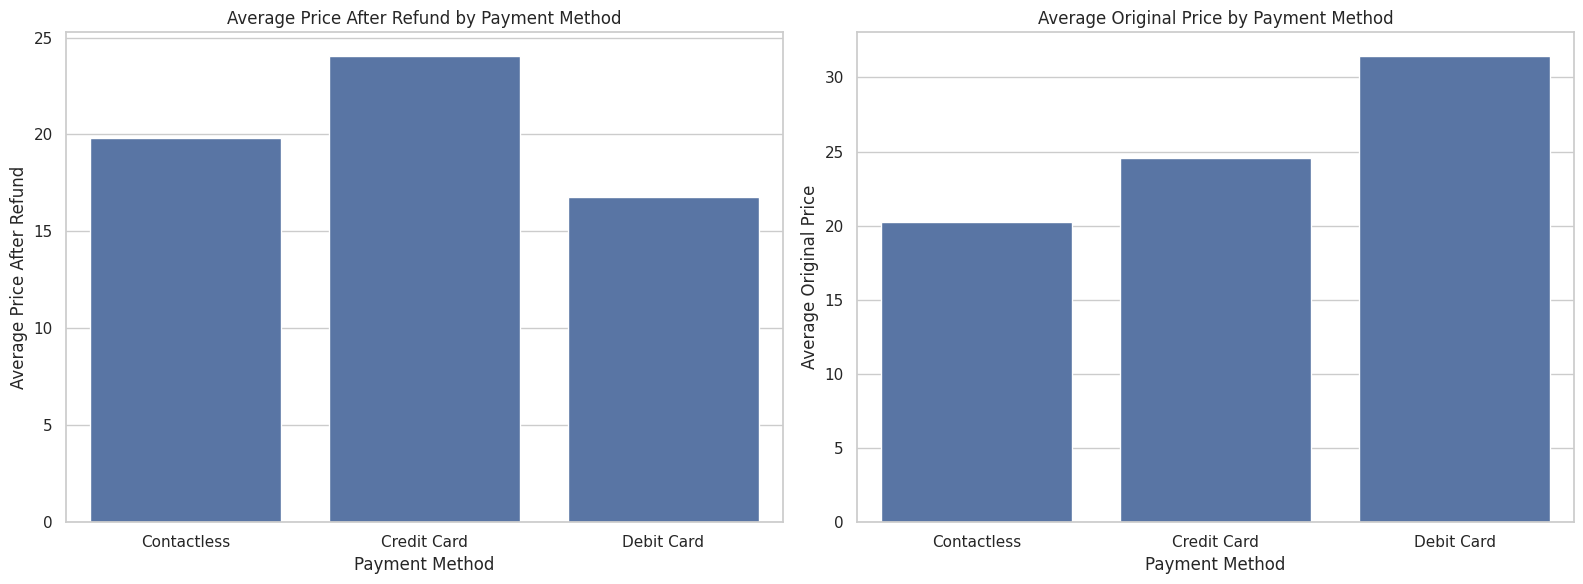

In [87]:
# Hypothesis 4: Credit Card transactions have a higher average value compared to Debit Card transactions.
avg_transaction_after_refund = df.groupby('Payment Method')['Price After Refund'].mean().reset_index()
avg_original_price = df.groupby('Payment Method')['Price'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=avg_transaction_after_refund, x='Payment Method', y='Price After Refund', ax=axes[0])
axes[0].set_title('Average Price After Refund by Payment Method')
axes[0].set_ylabel('Average Price After Refund')
axes[0].set_xlabel('Payment Method')

sns.barplot(data=avg_original_price, x='Payment Method', y='Price', ax=axes[1])
axes[1].set_title('Average Original Price by Payment Method')
axes[1].set_ylabel('Average Original Price')
axes[1].set_xlabel('Payment Method')

plt.tight_layout()
plt.show()

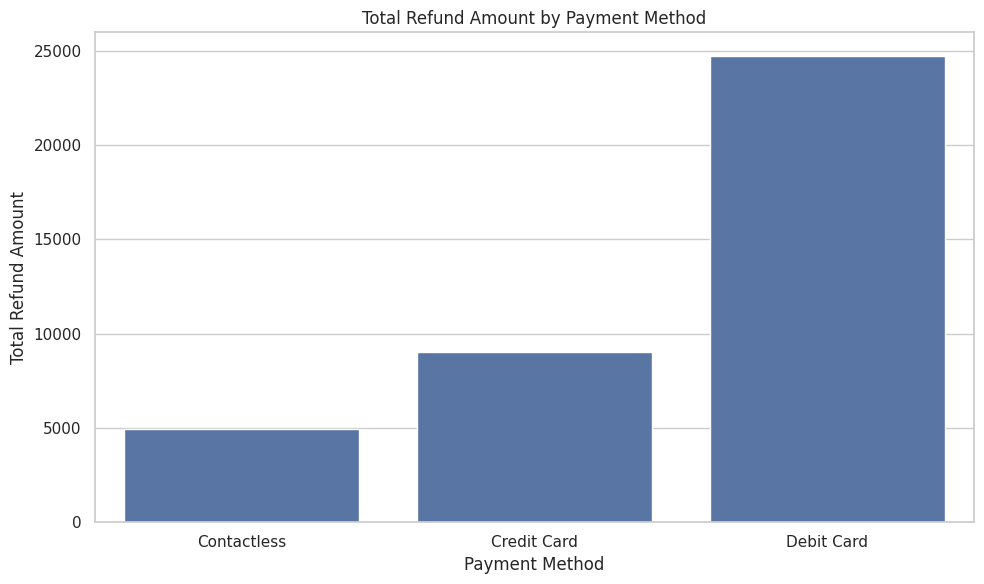

In [88]:
refunded_tickets = df[df['Refund Request'] == 'Yes']
total_refund_amount = refunded_tickets.groupby('Payment Method')['Price'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=total_refund_amount, x='Payment Method', y='Price')
plt.title('Total Refund Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Refund Amount')
plt.tight_layout()
plt.show()

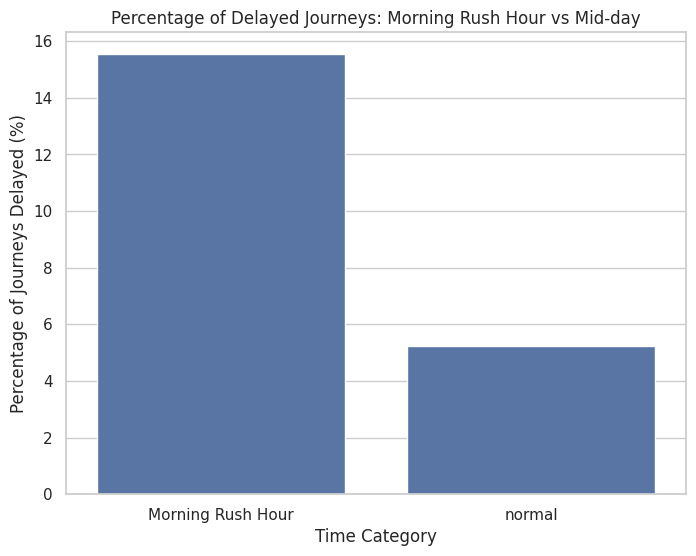

In [89]:
# Hypothesis 5: Journeys scheduled during Rush Hour (07:00–09:00) are more likely to be delayed than normal journeys.
df["departure time DT"] = pd.to_datetime(df['Departure Time'])
df["Hour"]=df['departure time DT'].dt.hour


def categorize_time(hour):
    if 7 <= hour <= 9:
        return 'Morning Rush Hour'
    else:
        return 'normal'

df['Time Category'] = df['Hour'].apply(categorize_time)

delay_stats = df.groupby('Time Category')['Journey Status'].value_counts(normalize=True).unstack() * 100
delay_stats = delay_stats.reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=delay_stats, x='Time Category', y='Delayed')
plt.title('Percentage of Delayed Journeys: Morning Rush Hour vs Mid-day')
plt.ylabel('Percentage of Journeys Delayed (%)')
plt.xlabel('Time Category')
plt.show()

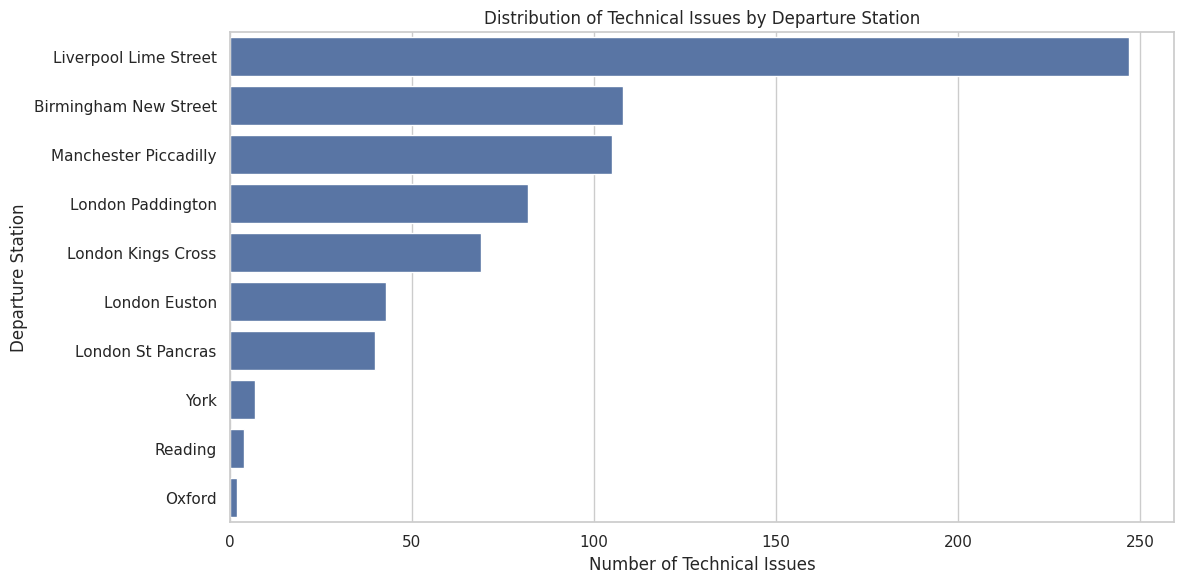

In [90]:
# Hypothesis 6: Technical issues as a cause for delay are station-specific.
technical_issues_df = df[df['Reason for Delay'] == 'Technical Issue']

station_counts = technical_issues_df['Departure Station'].value_counts().reset_index()
station_counts.columns = ['Departure Station', 'Technical Issue Count']

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=station_counts, x='Technical Issue Count', y='Departure Station')
plt.title('Distribution of Technical Issues by Departure Station')
plt.xlabel('Number of Technical Issues')
plt.ylabel('Departure Station')
plt.tight_layout()

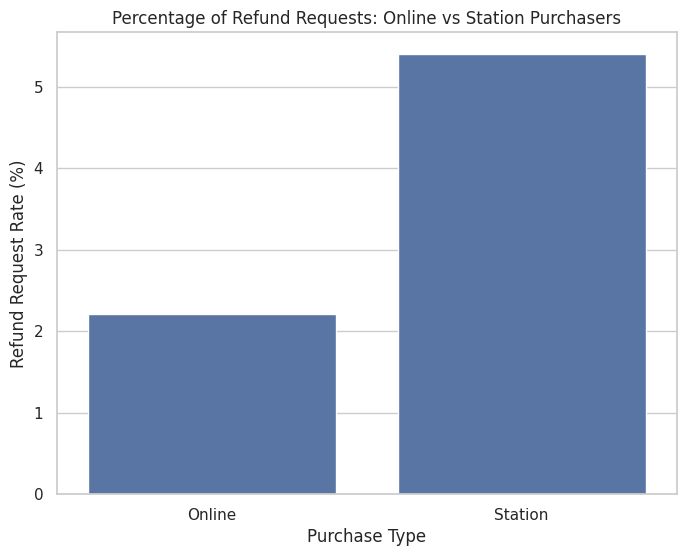

In [91]:
# Hypothesis 7: Online purchasers are more likely to request refunds through the system than Station purchasers.
refund_stats = df.groupby('Purchase Type')['Refund Request'].value_counts(normalize=True).unstack() * 100
refund_stats = refund_stats.reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=refund_stats, x='Purchase Type', y='Yes')
plt.title('Percentage of Refund Requests: Online vs Station Purchasers')
plt.ylabel('Refund Request Rate (%)')
plt.xlabel('Purchase Type')
plt.show()

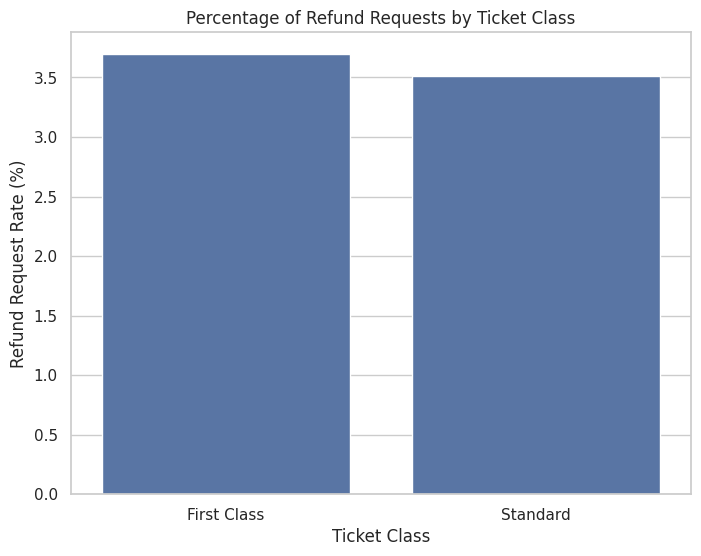

In [92]:
# Hypothesis 8: First Class passengers are less likely to request a refund compared to other classes.
refund_rate = df.groupby('Ticket Class')['Refund Request'].value_counts(normalize=True).unstack() * 100
refund_rate = refund_rate.reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=refund_rate, x='Ticket Class', y='Yes')
plt.title('Percentage of Refund Requests by Ticket Class')
plt.ylabel('Refund Request Rate (%)')
plt.xlabel('Ticket Class')
plt.show()

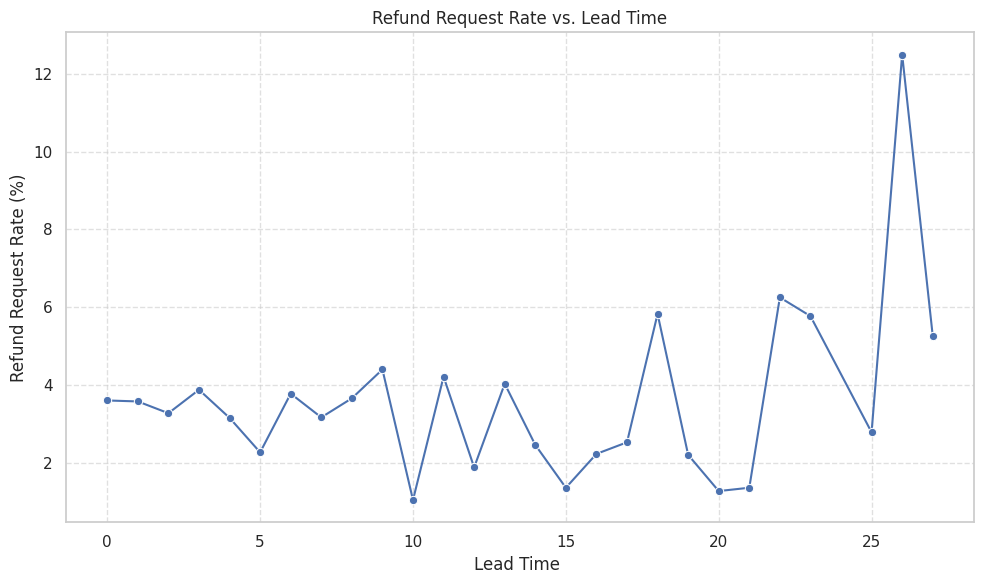

In [93]:
# Hypothesis 9: As the lead time between purchase and travel increases, the refund rate also increases.
refund_trend = df.groupby('Lead Time')['Refund Request'].value_counts(normalize=True).unstack() * 100
refund_trend = refund_trend.reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=refund_trend, x='Lead Time', y='Yes', marker='o')
plt.title('Refund Request Rate vs. Lead Time')
plt.xlabel('Lead Time ')
plt.ylabel('Refund Request Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Concolusion

**Hypothesis 1:** Passengers purchasing Anytime tickets pay significantly higher prices than any other ticket type. ->**True**

  

**Hypothesis 2:** Tickets purchased at the Station have a higher average price than those purchased Online. ->**True**

  

**Hypothesis 3:** First Class tickets are primarily purchased for long-distance routes. ->**True**


**Hypothesis 4:** Credit Card transactions have a higher average value compared to Debit Card transactions.  ->**False**

  

**Hypothesis 5:** Journeys scheduled during Rush Hour (07:00–09:00) are more likely to be delayed than normal journeys.  ->**True**

  

**Hypothesis 6:** Technical issues as a cause for delay are station-specific.  ->**True**

  

**Hypothesis 7:** Online purchasers are more likely to request refunds through the system than Station purchasers.  ->**False**

  

**Hypothesis 8:** First Class passengers are less likely to request a refund compared to other classes.  ->**False**

  

**Hypothesis 9:** As the lead time between purchase and travel increases, the refund rate also increases.  ->**True**


## `Hypothesis 1: The Impact of Delay Reasons on Customer Refund Behavior `

`Business Question:` Does the underlying reason for a train delay influence the passenger's likelihood to request a refund more than the actual duration of the delay?

`Hypotheses Formulation:`
Null Hypothesis ($H_0$): The specific reason for a delay has no significant impact on the refund request rate; all delays trigger refunds proportionally.

`Alternative Hypothesis ($H_1$):` Passengers are significantly more likely to request refunds for delays caused by company-controlled operational failures (e.g., Technical Issues) compared to uncontrollable external factors (e.g., Weather Conditions), regardless of the delay duration.

/tmp/ipykernel_1466/2750101155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=refund_by_reason, x='Reason for Delay', y='Yes', palette='Reds_r')


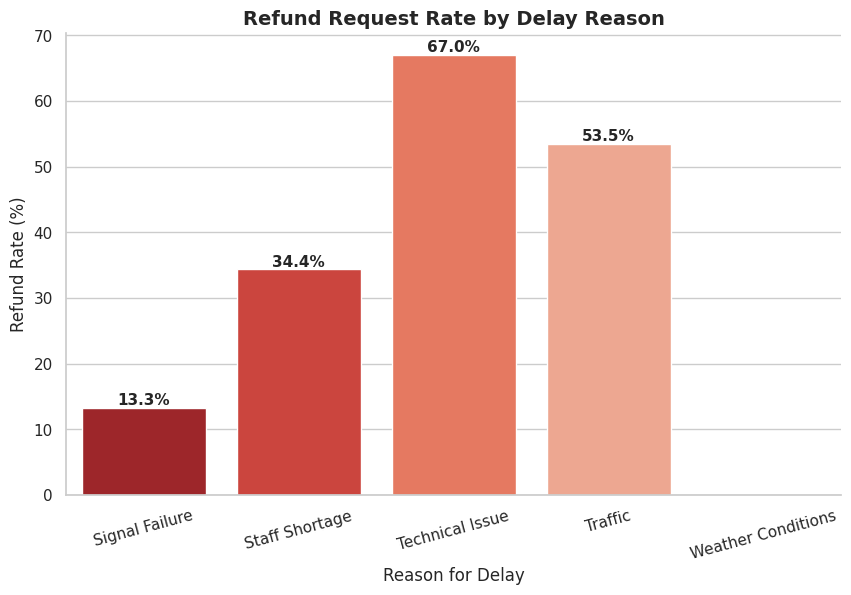

In [94]:
delayed_df = df[df['Delay in Minutes'] > 0].copy()
refund_by_reason = delayed_df.groupby('Reason for Delay')['Refund Request'].value_counts(normalize=True).unstack() * 100
refund_by_reason = refund_by_reason.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=refund_by_reason, x='Reason for Delay', y='Yes', palette='Reds_r')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Refund Request Rate by Delay Reason', fontsize=14, fontweight='bold')
plt.ylabel('Refund Rate (%)')
plt.xticks(rotation=15)
sns.despine()
plt.show()

In [95]:
route_analysis = df.groupby('Route').agg(
    Total_Revenue=('Price', 'sum'),
    Total_Trips=('Transaction ID', 'count'),
    Delayed_Trips=('Delay in Minutes', lambda x: (x > 0).sum())
).reset_index()
route_analysis['Delay_Rate_%'] = (route_analysis['Delayed_Trips'] / route_analysis['Total_Trips']) * 100
top_routes = route_analysis.sort_values(by='Total_Revenue', ascending=False).head(5)
print(top_routes[['Route', 'Total_Revenue', 'Delay_Rate_%']])

                                         Route  Total_Revenue  Delay_Rate_%
30                  London Kings Cross to York         183193      3.289138
19      Liverpool Lime Street to London Euston         113299     70.738377
35                London Paddington to Reading          65368      1.704105
25      London Euston to Manchester Piccadilly          61004      0.000000
36  London St Pancras to Birmingham New Street          52869      0.000000
